---
# **Birrefringencia Constitutiva y Curvas Críticas en el Agujero Negro Rotante de García-Díaz**
---

## **Figuras y tablas de contornos críticos birrefringentes**

Este cuaderno reproduce las figuras de contornos críticos y las tablas de observables geométricos del manuscrito.

La cadena computacional es

$$
\Delta(r),\ A_s(r),\ B_s(\theta)
\longrightarrow
\{\xi_s(r_c),k_s(r_c)\}
\longrightarrow
\Gamma_s
\longrightarrow
\{\Delta_{\rm cel},\Delta_{\rm scr},d_s,w_{\rm br},f_{\rm br}\}.
$$

Primero se generan las figuras de $\Gamma_+$ y $\Gamma_-$. Después se ejecutan los barridos numéricos que alimentan las tablas.

## **$(1)$ Preparación del entorno**

Cargamos las bibliotecas necesarias para el cálculo numérico, la construcción de tablas y la generación de las figuras.

In [1]:
import os                                                                       # Lee opciones del entorno
import warnings
from dataclasses import dataclass, replace                                      # Estructura parámetros del modelo
from pathlib import Path                                                        # Maneja rutas reproducibles
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd

import matplotlib as mpl                                                        # Ajusta el estilo gráfico global
import matplotlib.pyplot as plt                                                 # Construye figuras y curvas

from scipy.optimize import brentq                                               # Localiza raíces por intervalos
from matplotlib.ticker import FuncFormatter, MaxNLocator                        # Pule etiquetas y marcas de ejes


## **$(2)$ Figuras de contornos críticos**

Las figuras se construyen a partir de la parametrización completa de los contornos críticos. El caso (a=0) se evalúa mediante su límite esférico, mientras que los casos rotantes emplean las constantes críticas propias de cada rama óptica.

### **Parámetros visuales**

Fijamos una estética común para todas las figuras: proporciones, tipografía, grosor de líneas, colores y opciones de exportación. El objetivo es que la separación entre $\Gamma_+$ y $\Gamma_-$ sea visible sin sobrecargar la composición.

In [2]:
# ==============================================================================
#            Estilo gráfico para los contornos críticos
# ==============================================================================

FIG_WIDTH_THREE_PANEL = 7.10                                                    # Ancho final para tres paneles
FIG_HEIGHT_THREE_PANEL = 3.12                                                   # Altura compacta de la figura

LABEL_SIZE = 10.5                                                               # Tamaño de etiquetas de ejes
TICK_SIZE = 8.2                                                                 # Tamaño de marcas numéricas
TITLE_SIZE = 11.0                                                               # Tamaño de títulos de panel
LEGEND_SIZE = 8.6                                                               # Tamaño de la leyenda
PANEL_LABEL_SIZE = 11.2                                                         # Tamaño de las etiquetas (a), (b) y (c)

AXIS_LINEWIDTH = 0.72                                                           # Grosor del marco de los ejes
MAIN_LINEWIDTH_PLUS = 1.45                                                      # Grosor de la rama Γ+
MAIN_LINEWIDTH_MINUS = 1.45                                                     # Grosor de la rama Γ−
GRID_LINEWIDTH = 0.50                                                           # Grosor de la grilla auxiliar
REFERENCE_LINEWIDTH = 0.66                                                      # Grosor de líneas de referencia

PANEL_LABEL_X = -0.105                                                          # Posición horizontal de la etiqueta
PANEL_LABEL_Y = 1.085                                                           # Posición vertical de la etiqueta

FILL_CONTOURS = True                                                            # Activa el sombreado interno
FILL_ALPHA_PLUS = 0.080                                                         # Transparencia del relleno Γ+
FILL_ALPHA_MINUS = 0.060                                                        # Transparencia del relleno Γ−

COLORS = {
    "plus": "#1F4E79",                                                          # Color principal de Γ+
    "minus": "#B66A1E",                                                         # Color principal de Γ−

    "grid": "#d4d4d4",                                                          # Grilla suave de apoyo visual
    "axis": "#bfbfbf",                                                          # Marco discreto de los ejes
    "reference": "#8f8f8f",                                                     # Líneas guía y referencias
    "ticks": "#222222",                                                         # Color de marcas y números

    "shade_plus": "#1F4E79",                                                    # Relleno asociado a Γ+
    "shade_minus": "#B66A1E",                                                   # Relleno asociado a Γ−
}


def set_gd_figure_style():                                                      # Define la estética global del paper
    mpl.rcParams.update({
        "figure.dpi": 180,                                                      # Resolución cómoda en pantalla
        "savefig.dpi": 600,                                                     # Resolución alta para exportar
        "savefig.bbox": "standard",                                             # Conserva el encuadre definido

        "font.family": "serif",                                                 # Tipografía compatible con artículo
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",                                             # Matemática con estilo editorial

        "axes.linewidth": AXIS_LINEWIDTH,                                       # Grosor uniforme de los ejes
        "axes.edgecolor": COLORS["axis"],                                       # Marco visualmente ligero
        "axes.labelsize": LABEL_SIZE,                                           # Tamaño común de etiquetas
        "axes.titlesize": TITLE_SIZE,                                           # Tamaño común de títulos
        "axes.titleweight": "normal",                                           # Evita títulos visualmente pesados
        "axes.labelweight": "normal",                                           # Mantiene etiquetas sobrias
        "axes.titlepad": 6.5,                                                   # Separa título y panel

        "xtick.labelsize": TICK_SIZE,                                           # Tamaño de marcas en x
        "ytick.labelsize": TICK_SIZE,                                           # Tamaño de marcas en y
        "xtick.direction": "in",                                                # Marcas hacia el interior
        "ytick.direction": "in",                                                # Marcas hacia el interior
        "xtick.top": True,                                                      # Activa marcas superiores
        "ytick.right": True,                                                    # Activa marcas derechas
        "xtick.major.size": 3.7,                                                # Largo de marcas principales
        "ytick.major.size": 3.7,                                                # Largo de marcas principales
        "xtick.major.width": 0.68,                                              # Grosor de marcas en x
        "ytick.major.width": 0.68,                                              # Grosor de marcas en y
        "xtick.color": COLORS["ticks"],                                         # Color de marcas en x
        "ytick.color": COLORS["ticks"],                                         # Color de marcas en y

        "lines.solid_capstyle": "round",                                        # Extremos suaves en líneas continuas
        "lines.dash_capstyle": "round",                                         # Extremos suaves en líneas punteadas

        "legend.fontsize": LEGEND_SIZE,                                         # Leyenda compacta
        "legend.frameon": False,                                                # Elimina caja de leyenda
        "legend.handlelength": 2.8,                                             # Longitud de muestras de línea
        "legend.borderpad": 0.10,                                               # Reduce espacio interno
        "legend.labelspacing": 0.28,                                            # Compacta entradas verticales
        "legend.columnspacing": 1.9,                                            # Separa columnas de leyenda

        "pdf.fonttype": 42,                                                     # Exporta texto editable en PDF
        "ps.fonttype": 42,                                                      # Mantiene fuentes vectoriales
    })


def apply_axis_style(ax, grid=True):                                            # Aplica estilo local a cada panel
    ax.tick_params(
        direction="in",                                                         # Marcas hacia el interior
        top=True,                                                               # Marcas en borde superior
        right=True,                                                             # Marcas en borde derecho
        width=0.68,                                                             # Grosor de marcas
        length=3.7,                                                             # Largo de marcas
        pad=2.0,                                                                # Distancia entre marca y número
        color=COLORS["ticks"],                                                  # Color de marcas
        labelcolor=COLORS["ticks"],                                             # Color de etiquetas numéricas
    )

    for spine in ax.spines.values():
        spine.set_linewidth(AXIS_LINEWIDTH)                                     # Unifica grosor del marco
        spine.set_color(COLORS["axis"])                                         # Suaviza el contorno del panel

    if grid:
        ax.set_axisbelow(True)                                                  # Envía la grilla al fondo
        ax.grid(
            True,
            which="major",                                                      # Usa sólo marcas principales
            color=COLORS["grid"],                                               # Grilla de bajo contraste
            linestyle="-",                                                      # Trazo continuo y discreto
            linewidth=GRID_LINEWIDTH,                                           # Grosor fino de la grilla
            alpha=0.90,                                                         # Mantiene visibilidad controlada
        )


def add_panel_labels(axes, labels=None, x=PANEL_LABEL_X, y=PANEL_LABEL_Y):
    axes = list(axes)                                                           # Asegura una lista iterable

    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]                 # Genera (a), (b), ...

    for ax, lab in zip(axes, labels):
        ax.text(
            x,
            y,
            lab,
            transform=ax.transAxes,                                             # Posiciona relativo al panel
            ha="left",
            va="bottom",
            fontsize=PANEL_LABEL_SIZE,                                          # Mantiene jerarquía visual
            fontweight="normal",                                                # Evita énfasis innecesario
            color="0.08",                                                       # Negro suave
            clip_on=False,                                                      # Permite ubicar fuera del eje
        )


def save_figure(fig, pdf_path, png_path, dpi=600):                              # Exporta versiones final y revisión
    fig.savefig(pdf_path)                                                       # Guarda versión vectorial
    fig.savefig(png_path, dpi=dpi)                                              # Guarda versión rasterizada


### **Carpeta de salida**

Definimos una carpeta única para guardar las figuras generadas por el cuaderno. Esto mantiene separadas las salidas numéricas del código fuente y facilita reproducir, revisar o reemplazar las imágenes del paper.

In [3]:
# ==============================================================================
#                            Carpeta de salida
# ==============================================================================

OUTDIR = Path("salidas_GD_birefringencia") / "figuras"                          # Ruta común para las figuras
OUTDIR.mkdir(parents=True, exist_ok=True)                                       # Crea la carpeta si no existe

set_gd_figure_style()                                                           # Activa la estética del paper

### **Parámetros del modelo**

Concentramos los parámetros físicos, geométricos y numéricos en dos clases. La primera fija el modelo de García--Díaz y la posición del observador; la segunda controla la resolución del trazado y las tolerancias usadas en la construcción de los contornos críticos.

In [4]:
# ==============================================================================
#                  Parámetros del modelo y del trazado
# ==============================================================================

@dataclass
class GDModelParams:                                                            # Agrupa el modelo físico y el observador
    M: float = 1.0                                                              # Escala de masa
    a: float = 0.93                                                             # Parámetro de rotación
    p: float = 0.20                                                             # Carga magnética
    q: float = 0.30                                                             # Carga eléctrica
    beta: float = 1.0e-4                                                        # Acoplamiento no lineal
    r_obs: float = 8.0                                                          # Radio del observador
    theta_obs_deg: float = 85.0                                                 # Inclinación del observador en grados

    @property
    def theta_obs(self) -> float:                                               # Entrega la inclinación en radianes
        return np.deg2rad(self.theta_obs_deg)                                   # Convierte grados a radianes


@dataclass
class GDNumerics:                                                               # Controla resolución y tolerancias
    Nrc: int = 4500                                                             # Muestras del radio crítico
    Nphi_static: int = 1800                                                     # Muestras angulares del caso esférico

    r_crit_max: Optional[float] = None                                          # Corte radial superior opcional
    horizon_root_tol: float = 1.0e-9                                            # Tolerancia para raíces de horizonte
    eps_horizon: float = 1.0e-5                                                 # Separación mínima fuera del horizonte
    eps_root: float = 1.0e-12                                                   # Umbral para raíces degeneradas
    signature_tol: float = 1.0e-11                                              # Margen para condiciones de firma óptica

    static_spin_tol: float = 1.0e-12                                            # Umbral para tratar a≈0 como esférico

    small_a_threshold: float = 5.0e-2                                           # Umbral del régimen de giro pequeño
    small_a_window_factor: float = 20.0                                         # Amplía la ventana crítica para a pequeño
    small_a_min_window: float = 2.0e-3                                          # Ventana mínima cerca del límite esférico

### **Etiquetas y funciones auxiliares**

Definimos funciones auxiliares para rotular los paneles, cerrar curvas, reunir puntos proyectados y fijar límites comunes de pantalla. Estas rutinas no modifican la física del cálculo: sólo ordenan la visualización para que los contornos $\Gamma_+$ y $\Gamma_-$ puedan compararse de forma limpia entre paneles.

In [5]:
# ==============================================================================
#                    Etiquetas y funciones auxiliares
# ==============================================================================

def beta_panel_title(beta: float) -> str:                                       # Escribe la etiqueta de βM²
    if np.isclose(beta, 0.0):                                                   # Identifica el límite de Maxwell
        return r"$\beta M^2=0$"
    if np.isclose(beta, 5.0e-5):                                                # Caso usado en el barrido principal
        return r"$\beta M^2=5\times 10^{-5}$"
    if np.isclose(beta, 1.0e-4):                                                # Caso de referencia no lineal
        return r"$\beta M^2=10^{-4}$"
    if np.isclose(beta, 2.0e-4):                                                # Caso extendido del acoplamiento
        return r"$\beta M^2=2\times 10^{-4}$"

    exponent = int(np.floor(np.log10(abs(beta))))                               # Extrae el orden de magnitud
    mantissa = beta / 10.0**exponent                                            # Extrae la mantisa
    return rf"$\beta M^2={mantissa:.1f}\times 10^{{{exponent}}}$"


def spin_panel_title(a: float) -> str:                                          # Escribe la etiqueta de a/M
    if 1.0e-4 < abs(a) < 1.0e-2:                                                # Rotulación del límite casi esférico
        return r"$a/M\simeq0$"
    return rf"$a/M={a:.2f}$"                                                    # Rotulación de casos rotantes con 2 decimales


def close_curve(xs, ys):                                                        # Cierra una curva proyectada
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)

    mask = np.isfinite(xs) & np.isfinite(ys)                                    # Conserva sólo puntos finitos
    x = xs[mask]
    y = ys[mask]

    if len(x) < 6:                                                              # Evita cerrar trazas insuficientes
        return None, None

    if np.isclose(x[0], x[-1]) and np.isclose(y[0], y[-1]):                     # Detecta curvas ya cerradas
        return x, y

    return np.r_[x, x[0]], np.r_[y, y[0]]                                       # Añade el punto inicial al final


def collect_contour_points_from_result(res):                                    # Reúne puntos de ambas ramas
    xs_all = []
    ys_all = []

    if res is None:                                                             # Permite resultados vacíos
        return np.array([]), np.array([])

    for branch in ["plus", "minus"]:                                            # Recorre Γ+ y Γ−
        xs = np.asarray(res[branch]["xs"], dtype=float)                         # Lee puntos x de la rama
        ys = np.asarray(res[branch]["ys"], dtype=float)                         # Lee puntos y de la rama

        mask = np.isfinite(xs) & np.isfinite(ys)                                # Descarta valores no finitos
        xs_all.extend(xs[mask])                                                 # Agrega x válidos
        ys_all.extend(ys[mask])                                                 # Agrega y válidos

    return np.asarray(xs_all, dtype=float), np.asarray(ys_all, dtype=float)


def contour_limits_x_independent_y_common(
    results_list,
    padding=0.12,                                                               # Margen visual alrededor del dato
    min_half=0.70,                                                              # Semiancho mínimo de pantalla
    origin_margin=0.06,                                                         # Margen para incluir el origen
    round_step=0.05,                                                            # Redondeo limpio de límites
):
    panel_stats = []                                                            # Guarda estadísticas por panel
    common_half = min_half                                                      # Inicializa escala común

    for res in results_list:                                                    # Analiza cada panel
        xs_all, ys_all = collect_contour_points_from_result(res)

        if len(xs_all) < 10:                                                    # Detecta paneles sin curva útil
            stat = {
                "valid_limits": False,
                "cx": 0.0,
                "cy": 0.0,
                "xmin_data": np.nan,
                "xmax_data": np.nan,
                "ymin_data": np.nan,
                "ymax_data": np.nan,
                "half_x_data": np.nan,
                "half_y_data": np.nan,
            }
            panel_stats.append(stat)
            continue

        xmin, xmax = np.nanmin(xs_all), np.nanmax(xs_all)                       # Extremos horizontales
        ymin, ymax = np.nanmin(ys_all), np.nanmax(ys_all)                       # Extremos verticales

        cx = 0.5 * (xmin + xmax)                                                # Centro horizontal del panel
        cy = 0.5 * (ymin + ymax)                                                # Centro vertical de los datos

        half_x_data = 0.5 * (xmax - xmin) * (1.0 + padding)                     # Semiancho con margen
        half_y_data = 0.5 * (ymax - ymin) * (1.0 + padding)                     # Semialto con margen

        common_half = max(
            common_half,
            half_x_data,
            half_y_data,
            abs(cx) + origin_margin,                                            # Mantiene visible el eje x=0
            abs(cy) + origin_margin,                                            # Mantiene visible el eje y=0
        )

        panel_stats.append({
            "valid_limits": True,
            "cx": cx,
            "cy": cy,
            "xmin_data": xmin,
            "xmax_data": xmax,
            "ymin_data": ymin,
            "ymax_data": ymax,
            "half_x_data": half_x_data,
            "half_y_data": half_y_data,
        })

    common_half = round_step * np.ceil(common_half / round_step)                # Redondea la escala
    common_ylim = (-common_half, common_half)                                   # Usa el mismo eje y en todos

    panel_limits = []                                                           # Guarda límites finales

    for stat in panel_stats:
        cx = stat["cx"]                                                         # Centra cada panel en su curva

        xlim = (cx - common_half, cx + common_half)                             # Eje x centrado por panel
        ylim = common_ylim                                                      # Eje y común

        row = {
            **stat,
            "xlim_min": xlim[0],
            "xlim_max": xlim[1],
            "ylim_min": ylim[0],
            "ylim_max": ylim[1],
            "common_half": common_half,
        }

        panel_limits.append((xlim, ylim, row))

    return panel_limits, common_ylim, common_half


def screen_tick_formatter(x, pos):                                              # Formatea marcas de la pantalla
    if np.isclose(x, 0.0, atol=1.0e-12):                                        # Evita residuos numéricos en cero
        return r"$0$"

    s = f"{x:.2f}".rstrip("0").rstrip(".")                                      # Elimina decimales innecesarios

    if s == "-0":                                                               # Corrige el cero negativo
        s = "0"

    return rf"${s}$"                                                            # Devuelve etiqueta matemática


def set_screen_ticks_x_independent_y_common(ax, show_y_ticklabels=True):
    x_locator = MaxNLocator(
        nbins=5,                                                                # Limita marcas horizontales
        steps=[1, 2, 2.5, 5, 10],                                               # Prefiere separaciones limpias
        min_n_ticks=4,                                                          # Mantiene lectura suficiente
    )

    y_locator = MaxNLocator(
        nbins=7,                                                                # Permite más marcas verticales
        steps=[1, 2, 2.5, 5, 10],                                               # Usa pasos visualmente regulares
        min_n_ticks=5,                                                          # Evita ejes demasiado vacíos
    )

    ax.xaxis.set_major_locator(x_locator)                                       # Fija marcas principales en x
    ax.yaxis.set_major_locator(y_locator)                                       # Fija marcas principales en y

    ax.xaxis.set_major_formatter(FuncFormatter(screen_tick_formatter))          # Formato en x
    ax.yaxis.set_major_formatter(FuncFormatter(screen_tick_formatter))          # Formato en y

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE,                                                    # Tamaño coherente con el paper
        pad=2.0,                                                                # Separa marcas y etiquetas
        labelleft=show_y_ticklabels,                                            # Oculta y en paneles internos
    )


def add_screen_origin_marker(ax):                                               # Marca el origen de la pantalla
    ax.axhline(
        0.0,
        color=COLORS["reference"],                                              # Línea guía horizontal
        linewidth=REFERENCE_LINEWIDTH,
        linestyle=(0, (2.2, 2.0)),                                              # Trazo punteado discreto
        zorder=4,
    )

    ax.axvline(
        0.0,
        color=COLORS["reference"],                                              # Línea guía vertical
        linewidth=REFERENCE_LINEWIDTH,
        linestyle=(0, (2.2, 2.0)),                                              # Trazo punteado discreto
        zorder=4,
    )

    ax.scatter(
        [0.0],
        [0.0],
        s=14,                                                                   # Tamaño del marcador central
        marker="o",
        facecolor="white",                                                      # Interior limpio
        edgecolor="0.14",                                                       # Borde visible
        linewidth=0.70,
        zorder=9,
        clip_on=False,                                                          # Mantiene el marcador completo
    )

    ax.annotate(
        r"$O$",
        xy=(0.0, 0.0),
        xytext=(4, 4),                                                          # Desplaza la etiqueta del punto
        textcoords="offset points",
        fontsize=7.6,
        color="0.12",
        zorder=10,
    )


### **Cálculo de los contornos críticos**

Encapsulamos en una clase la construcción numérica de los contornos críticos. La rutina localiza el horizonte exterior, evalúa los factores ópticos de cada rama, obtiene las constantes críticas y proyecta las direcciones admisibles sobre la pantalla local del observador. Esta es la pieza central que produce las curvas $\Gamma_+$ y $\Gamma_-$ usadas en las figuras del manuscrito.

In [6]:
# ==============================================================================
#                     Cálculo de contornos críticos
# ==============================================================================

class GDBirefringentContours:
    """
    Construye los contornos críticos birefringentes Γ+ y Γ−.

    La clase localiza el horizonte exterior admisible, evalúa las
    constantes críticas de cada rama óptica y proyecta las direcciones
    visibles sobre la pantalla local del observador.
    """

    def __init__(
        self,
        model: GDModelParams,
        num: GDNumerics,
        sigma_r: int = +1,
    ):
        self.model = model                                                      # Parámetros físicos del modelo
        self.num = num                                                          # Parámetros numéricos del trazado
        self.sigma_r = sigma_r                                                  # Orientación radial del rayo

        self.M = float(model.M)                                                 # Masa en unidades geométricas
        self.a = float(model.a)                                                 # Rotación
        self.p = float(model.p)                                                 # Carga magnética
        self.q = float(model.q)                                                 # Carga eléctrica
        self.beta = float(model.beta)                                           # Acoplamiento no lineal
        self.r_obs = float(model.r_obs)                                         # Posición radial del observador
        self.theta_obs = float(model.theta_obs)                                 # Inclinación del observador

        if not (0.0 < self.theta_obs < np.pi):
            raise ValueError("The observer inclination must satisfy 0 < theta_obs < pi.")

        self.r_plus, self.horizon_roots = self.find_outer_horizon()             # Horizonte exterior

        if not np.isfinite(self.r_plus):
            raise RuntimeError("No admissible outer horizon below the observer was found.")

        if self.r_obs <= self.r_plus:
            raise ValueError(
                f"The observer must satisfy r_obs > r_+. "
                f"Here r_obs={self.r_obs:.8f}, r_+={self.r_plus:.8f}."
            )

    @property
    def Q2(self) -> float:
        return self.p * self.p + self.q * self.q                                # Carga diónica cuadrática

    def Sigma(self, r: float, th: float) -> float:
        return r * r + self.a * self.a * np.cos(th) ** 2                        # Bloque geométrico Σ

    def Delta(self, r: float) -> float:
        g = 1.0 - self.beta * (r * r + self.a * self.a)                         # Factor no lineal radial
        return r * r + self.a * self.a - 2.0 * self.M * r + self.Q2 * g * g

    def Delta_prime(self, r: float) -> float:
        g = 1.0 - self.beta * (r * r + self.a * self.a)                         # Derivada de Δ
        return 2.0 * r - 2.0 * self.M - 4.0 * self.beta * self.Q2 * r * g

    def horizon_polynomial_roots(self) -> List[float]:
        """Devuelve las raíces reales positivas de Δ(r)=0."""

        Q2 = self.Q2

        if abs(self.beta) < 1.0e-16:                                            # Usa la forma cuadrática del límite Maxwell
            coeffs = [1.0, -2.0 * self.M, self.a * self.a + Q2]
        else:
            c4 = Q2 * self.beta * self.beta                                     # Término r⁴ inducido por la NLED
            c3 = 0.0                                                            # No aparece término cúbico en Δ(r)
            c2 = (
                1.0
                - 2.0 * self.beta * Q2
                + 2.0 * self.beta * self.beta * Q2 * self.a * self.a
            )                                                                   # Coeficiente efectivo de r²
            c1 = -2.0 * self.M                                                  # Término lineal gravitacional
            c0 = self.a * self.a + Q2 * (1.0 - self.beta * self.a * self.a) ** 2# Término independiente
            coeffs = [c4, c3, c2, c1, c0]                                       # Polinomio Δ(r)=0

        roots = np.roots(coeffs)                                                # Calcula todas las raíces complejas

        real_pos = []                                                           # Conserva sólo raíces físicas candidatas
        for z in roots:
            if abs(z.imag) < self.num.horizon_root_tol and z.real > 0.0:        # Acepta raíces reales positivas
                rr = float(z.real)                                              # Descarta la parte imaginaria numérica
                if np.isfinite(rr):                                             # Evita raíces no numéricas
                    real_pos.append(rr)

        return sorted(real_pos)                                                 # Ordena de interior a exterior

    def find_outer_horizon(self) -> Tuple[float, List[float]]:
        roots = self.horizon_polynomial_roots()

        if not roots:
            return np.nan, []

        candidates = [r for r in roots if r < self.r_obs]                       # Horizontes bajo el observador

        if not candidates:
            return np.nan, roots

        return max(candidates), roots                                           # Horizonte exterior admisible

    @staticmethod
    def alpha(branch: str) -> float:
        if branch == "+":
            return 8.0                                                          # Peso óptico de Γ+
        if branch == "-":
            return -4.0                                                         # Peso óptico de Γ−
        raise ValueError("branch must be '+' or '-'.")

    def A_s(self, r: float, branch: str) -> float:
        return 1.0 + self.beta * self.alpha(branch) * r * r                     # Factor radial óptico

    def A_s_prime(self, r: float, branch: str) -> float:
        return 2.0 * self.beta * self.alpha(branch) * r                         # Derivada de A_s

    def B_s(self, th: float, branch: str) -> float:
        return 1.0 - self.beta * self.alpha(branch) * self.a * self.a * np.cos(th) ** 2

    def static_reference_radius(self, branch: str) -> Optional[float]:
        """Calcula el radio crítico en el límite esférico de una rama óptica."""

        def F(r):
            A = self.A_s(r, branch)
            return self.Delta(r) / A                                            # Potencial radial efectivo

        def F_prime(r):
            A = self.A_s(r, branch)
            Ap = self.A_s_prime(r, branch)
            return (self.Delta_prime(r) * A - self.Delta(r) * Ap) / (A * A)     # Derivada de Δ/A

        def h(r):
            return r * F_prime(r) - 4.0 * F(r)                                  # Condición crítica esférica

        rlo = self.r_plus + self.num.eps_horizon                                # Evita evaluar exactamente en el horizonte
        rhi = self.num.r_crit_max

        if rhi is None:
            rhi = min(self.r_obs * 0.999, 50.0)                                 # Corte seguro bajo el observador

        xs = np.linspace(rlo, rhi, max(8000, self.num.Nrc))                     # Malla fina para detectar cambios de signo
        vals = np.array([h(x) for x in xs], dtype=float)                        # Evalúa la condición crítica en la malla

        roots = []                                                              # Guarda raíces refinadas

        for i in range(len(xs) - 1):
            f1, f2 = vals[i], vals[i + 1]                                       # Valores en extremos del intervalo

            if not np.isfinite(f1) or not np.isfinite(f2):
                continue

            if f1 == 0.0:
                roots.append(xs[i])                                             # Caso raro: la malla cae justo en la raíz
            elif f1 * f2 < 0.0:                                                 # Cambio de signo: hay una raíz dentro
                try:
                    roots.append(
                        brentq(
                            h,
                            xs[i],
                            xs[i + 1],
                            xtol=1.0e-13,
                            rtol=1.0e-13,
                        )
                    )
                except Exception:                                               # Refina la raíz con un método robusto
                    pass                                                        # Omite intervalos numéricamente problemáticos

        if not roots:
            return None                                                         # No se encontró radio crítico admisible

        return float(roots[0])                                                  # Selecciona la primera raíz crítica exterior

    def trace_static_branch(self, branch: str) -> Dict[str, Any]:
        rc = self.static_reference_radius(branch)

        if rc is None or not np.isfinite(rc):
            raise RuntimeError(f"No static critical radius found for branch {branch}.")

        Delta_c = self.Delta(rc)
        A_c = self.A_s(rc, branch)

        if Delta_c <= 0.0 or A_c <= self.num.signature_tol:
            raise RuntimeError(f"Invalid static critical radius for branch {branch}.")

        k_s = A_c * rc**4 / Delta_c                                             # Constante crítica esférica

        Delta_o = self.Delta(self.r_obs)
        A_o = self.A_s(self.r_obs, branch)

        if Delta_o <= 0.0 or A_o <= self.num.signature_tol:
            raise RuntimeError(f"Invalid observer domain for branch {branch}.")

        R_o = self.r_obs**4 - Delta_o * k_s / A_o                               # Potencial radial en el observador

        if R_o < -1.0e-10:
            raise RuntimeError(f"No visible static contour for branch {branch}.")

        R_o = max(R_o, 0.0)

        p1 = self.sigma_r * np.sqrt(R_o) / (self.r_obs * np.sqrt(Delta_o))
        pT = np.sqrt(max(k_s, 0.0)) / self.r_obs

        K1 = A_o * p1                                                           # Dirección radial transportada
        KT = pT                                                                 # Dirección angular transversal

        norm = np.sqrt(K1 * K1 + KT * KT)

        if not np.isfinite(norm) or norm <= 0.0:
            raise RuntimeError(f"Invalid local direction norm for branch {branch}.")

        n1 = K1 / norm                                                          # Componente radial normalizada
        nT = KT / norm                                                          # Componente transversal normalizada

        phi = np.linspace(0.0, 2.0 * np.pi, self.num.Nphi_static, endpoint=False)

        n2 = nT * np.sin(phi)
        n3 = nT * np.cos(phi)

        denom = 1.0 + n1                                                        # Denominador estereográfico

        if abs(denom) < 1.0e-12:
            raise RuntimeError(f"Static projection singular for branch {branch}.")

        X = 2.0 * n3 / denom                                                    # Coordenada horizontal de pantalla
        Y = 2.0 * n2 / denom                                                    # Coordenada vertical de pantalla

        xs = np.r_[X, X[0]]                                                     # Cierra la curva circular
        ys = np.r_[Y, Y[0]]

        return {
            "branch": branch,
            "mode": "static",
            "xs": xs,
            "ys": ys,
            "rc": np.array([rc]),
            "n_valid": len(phi),
            "critical_radius": rc,
            "k_static": k_s,
        }

    def critical_constants_rotating(self, r: float, branch: str):
        """Evalúa ξ_s(r_c) y k_s(r_c) a partir de la condición de raíz doble."""

        Delta_c = self.Delta(r)                                                 # Δ evaluada en el radio crítico
        Delta_p = self.Delta_prime(r)                                           # Δ' evaluada en el radio crítico

        A_c = self.A_s(r, branch)                                               # Factor radial óptico de la rama
        A_p = self.A_s_prime(r, branch)                                         # Derivada del factor radial óptico

        D_s = Delta_p * A_c - Delta_c * A_p                                     # Denominador de la raíz doble

        if not np.isfinite(D_s) or abs(D_s) < self.num.eps_root:
            return None                                                         # Evita puntos degenerados de la parametrización

        if Delta_c <= 0.0 or A_c <= self.num.signature_tol:
            return None                                                         # Exige región exterior y firma óptica regular

        xi_s = ((r * r + self.a * self.a) * D_s - 4.0 * r * Delta_c * A_c) / (
            self.a * D_s
        )                                                                       # Constante crítica ξ_s(r_c)

        k_s = 16.0 * r * r * Delta_c * (A_c**3) / (D_s * D_s)                   # Constante crítica k_s(r_c) tipo Carter

        if not np.all(np.isfinite([xi_s, k_s, D_s])):
            return None                                                         # Descarta valores no físicos o no numéricos

        return xi_s, k_s, D_s

    def critical_grid_rotating(self, branch: str):
        r_lower = self.r_plus + self.num.eps_horizon
        r_upper = self.num.r_crit_max

        if r_upper is None:
            r_upper = min(self.r_obs * 0.999, 30.0)                             # Escaneo dentro del dominio local

        if abs(self.a) < self.num.small_a_threshold:
            r0 = self.static_reference_radius(branch)

            if r0 is not None:
                width = max(
                    self.num.small_a_window_factor * abs(self.a),
                    self.num.small_a_min_window,
                )
                r_lower = max(self.r_plus + self.num.eps_horizon, r0 - width)
                r_upper = min(self.r_obs * 0.999, r0 + width)

        if r_upper <= r_lower:
            raise RuntimeError("Invalid critical-radius scan interval.")

        return np.linspace(r_lower, r_upper, self.num.Nrc)

    def project_rotating_point(self, r_c: float, branch: str, varsigma: int = +1):
        """Proyecta un punto crítico rotante sobre la pantalla local."""

        crit = self.critical_constants_rotating(r_c, branch)

        if crit is None:
            return None                                                         # El radio no produce constantes críticas válidas

        xi_s, k_s, D_s = crit

        th = self.theta_obs                                                     # Inclinación del observador
        st = np.sin(th)                                                         # Factor sinθ del observador

        if abs(st) < 1.0e-12:
            return None                                                         # Evita la singularidad del eje polar

        Delta_o = self.Delta(self.r_obs)                                        # Δ en el observador
        Sigma_o = self.Sigma(self.r_obs, th)                                    # Σ en el observador

        A_o = self.A_s(self.r_obs, branch)                                      # Factor radial óptico local
        B_o = self.B_s(th, branch)                                              # Factor angular óptico local

        if Delta_o <= 0.0 or Sigma_o <= 0.0:
            return None                                                         # Requiere observador en región exterior regular

        if A_o <= self.num.signature_tol or B_o <= self.num.signature_tol:
            return None                                                         # Requiere firma óptica bien definida

        P_o = self.r_obs * self.r_obs + self.a * self.a - self.a * xi_s         # Bloque radial observado
        Q_o = xi_s - self.a * st * st                                           # Bloque angular observado

        Theta_o = k_s / B_o - (Q_o * Q_o) / (st * st)                           # Potencial angular en el observador
        R_o = P_o * P_o - (Delta_o / A_o) * k_s                                 # Potencial radial en el observador

        if Theta_o < -1.0e-10 or R_o < -1.0e-10:
            return None                                                         # El punto crítico no llega al observador

        Theta_o = max(Theta_o, 0.0)                                             # Limpia residuos negativos pequeños
        R_o = max(R_o, 0.0)                                                     # Limpia residuos negativos pequeños

        p1 = self.sigma_r * np.sqrt(R_o) / np.sqrt(Delta_o * Sigma_o)           # Componente radial del covector
        p2 = varsigma * np.sqrt(Theta_o) / np.sqrt(Sigma_o)                     # Componente polar del covector
        p3 = Q_o / (np.sqrt(Sigma_o) * st)                                      # Componente azimutal del covector

        K1 = A_o * p1                                                           # Flujo óptico radial
        K2 = B_o * p2                                                           # Flujo óptico polar
        K3 = B_o * p3                                                           # Flujo óptico azimutal

        norm = np.sqrt(K1 * K1 + K2 * K2 + K3 * K3)                             # Norma espacial local

        if not np.isfinite(norm) or norm <= 0.0:
            return None                                                         # Evita direcciones degeneradas

        n1 = K1 / norm                                                          # Coseno director radial
        n2 = K2 / norm                                                          # Coseno director polar
        n3 = K3 / norm                                                          # Coseno director azimutal

        denom = 1.0 + n1                                                        # Denominador de la estereografía

        if abs(denom) < 1.0e-12:
            return None                                                         # Evita singularidad de proyección

        X = 2.0 * n3 / denom                                                    # Proyección estereográfica en X
        Y = 2.0 * n2 / denom                                                    # Proyección estereográfica en Y

        if not np.all(np.isfinite([X, Y, n1, n2, n3])):
            return None                                                         # Exige una dirección proyectada finita

        return {
            "r_c": r_c,
            "X": X,
            "Y": Y,
            "n1": n1,
            "n2": n2,
            "n3": n3,
            "xi": xi_s,
            "k": k_s,
            "Theta_o": Theta_o,
            "R_o": R_o,
        }

    @staticmethod
    def longest_true_segment(mask: np.ndarray) -> Tuple[int, int]:
        best_start, best_end = 0, -1
        current_start = None

        for i, val in enumerate(mask):
            if val and current_start is None:
                current_start = i                                               # Inicia un tramo visible

            is_last = (i == len(mask) - 1)

            if current_start is not None and ((not val) or is_last):
                current_end = i if not val else i + 1

                if current_end - current_start > best_end - best_start:
                    best_start, best_end = current_start, current_end

                current_start = None

        return best_start, best_end                                             # Conserva el tramo visible mayor

    def trace_rotating_branch(self, branch: str) -> Dict[str, Any]:
        r_grid = self.critical_grid_rotating(branch)

        upper_rows = []
        lower_rows = []
        valid = []

        for r_c in r_grid:
            up = self.project_rotating_point(r_c, branch, varsigma=+1)
            lo = self.project_rotating_point(r_c, branch, varsigma=-1)

            if up is None or lo is None:
                upper_rows.append(None)
                lower_rows.append(None)
                valid.append(False)
            else:
                upper_rows.append(up)
                lower_rows.append(lo)
                valid.append(True)

        valid = np.array(valid, dtype=bool)
        s, e = self.longest_true_segment(valid)

        if e - s < 12:
            raise RuntimeError(
                f"No sufficiently long visible segment found for branch {branch}. "
                f"Valid points: {valid.sum()} / {len(valid)}."
            )

        upper_rows = upper_rows[s:e]
        lower_rows = lower_rows[s:e]

        keys = ["r_c", "X", "Y", "n1", "n2", "n3", "xi", "k", "Theta_o", "R_o"]

        def rows_to_array(rows):
            return np.array([[row[k] for k in keys] for row in rows], dtype=float)

        upper = rows_to_array(upper_rows)
        lower = rows_to_array(lower_rows)

        xs = np.r_[upper[:, 1], lower[::-1, 1], upper[0, 1]]                    # Mitad superior + inferior
        ys = np.r_[upper[:, 2], lower[::-1, 2], upper[0, 2]]                    # Curva cerrada proyectada

        return {
            "branch": branch,
            "mode": "rotating",
            "xs": xs,
            "ys": ys,
            "rc": upper[:, 0],
            "n_valid": len(upper),
            "critical_radius": np.nan,
        }

    def run(self) -> Dict[str, Any]:
        """Ejecuta la construcción completa para Γ+ y Γ−."""

        if abs(self.a) <= self.num.static_spin_tol:
            plus = self.trace_static_branch("+")                                # Rama Γ+ en el límite esférico
            minus = self.trace_static_branch("-")                               # Rama Γ− en el límite esférico
            mode = "static"
        else:
            plus = self.trace_rotating_branch("+")                              # Rama Γ+ rotante
            minus = self.trace_rotating_branch("-")                             # Rama Γ− rotante
            mode = "rotating"

        return {
            "plus": plus,
            "minus": minus,
            "mode": mode,
            "r_plus": self.r_plus,
            "horizon_roots": self.horizon_roots,
            "model": self.model,
            "observer": {
                "r_obs": self.r_obs,
                "theta_obs_deg": self.model.theta_obs_deg,
            },
        }

### **Construcción y guardado de figuras**

En esta celda se automatiza la producción de las figuras principales. Primero se define una rutina para ejecutar un caso individual del modelo; luego se implementa un barrido sobre un parámetro físico o geométrico; finalmente, se construye una figura de tres paneles donde se comparan los contornos críticos $\Gamma_+$ y $\Gamma_-$ en la pantalla local del observador. Cada figura se exporta en formato vectorial y rasterizado para su uso en el manuscrito y en el repositorio.

In [7]:
# ==============================================================================
#                     Construcción y guardado de figuras
# ==============================================================================

def run_case(model: GDModelParams, num: GDNumerics) -> Dict[str, Any]:
    tracer = GDBirefringentContours(
        model=model,
        num=num,
        sigma_r=+1,                                                             # Orientación radial local usada en la proyección
    )

    return tracer.run()                                                         # Calcula Γ+ y Γ− para este modelo


def compute_scan(param_name: str, values, base_model: GDModelParams, num: GDNumerics):
    results = []                                                                # Guarda los resultados del barrido

    for value in values:
        model_i = replace(
            base_model,
            **{param_name: value},
        )                                                                       # Cambia sólo el parámetro barrido

        try:
            with warnings.catch_warnings():
                warnings.simplefilter(
                    "ignore",
                    RuntimeWarning,
                )                                                               # Oculta avisos esperables cerca de fronteras numéricas

                res = run_case(model_i, num)                                    # Ejecuta el cálculo para este valor

            results.append(res)                                                 # Conserva el caso válido

        except Exception:
            results.append(None)                                                # Marca el caso fallido sin detener el barrido

    return results


def plot_contour_triptych(
    results_list,
    values,
    title_function,
    filename,
    padding=0.12,
    min_half=0.70,
    origin_margin=0.06,
    round_step=0.05,
    axis_label_x=r"$X/M$",
    global_axis_label_y=r"$Y/M$",
):
    panel_limits, common_ylim, common_half = contour_limits_x_independent_y_common(
        results_list=results_list,
        padding=padding,
        min_half=min_half,
        origin_margin=origin_margin,
        round_step=round_step,
    )                                                                           # Define límites comparables entre paneles

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(FIG_WIDTH_THREE_PANEL, FIG_HEIGHT_THREE_PANEL),
        dpi=230,
        constrained_layout=False,                                               # Mantiene el ajuste final bajo control manual
        sharex=False,                                                           # Permite centrar cada panel en su contorno
        sharey=True,                                                            # Conserva una escala vertical común
    )

    legend_handles = None                                                       # Se define con el primer panel válido
    legend_labels = None

    for j, (ax, value, res, lim_pack) in enumerate(
        zip(axes, values, results_list, panel_limits)
    ):
        xlim, ylim, _ = lim_pack                                                # Límites del panel actual

        apply_axis_style(ax, grid=True)                                         # Aplica la estética común del paper

        ax.set_xlim(*xlim)                                                      # Fija el rango horizontal del panel
        ax.set_ylim(*common_ylim)                                               # Fija el rango vertical común

        ax.set_aspect(
            "equal",
            adjustable="box",
            anchor="C",
        )                                                                       # Preserva proporciones geométricas

        try:
            ax.set_box_aspect(1.0)                                              # Fuerza panel cuadrado si está disponible
        except Exception:
            pass                                                                # Mantiene compatibilidad con versiones antiguas

        set_screen_ticks_x_independent_y_common(
            ax,
            show_y_ticklabels=(j == 0),
        )                                                                       # Muestra etiquetas de Y sólo en el primer panel

        ax.set_title(
            title_function(value),
            fontsize=TITLE_SIZE,
            pad=6.5,
            fontweight="normal",
        )                                                                       # Título físico del valor barrido

        ax.set_xlabel(
            axis_label_x,
            fontsize=LABEL_SIZE,
            labelpad=5.5,
            fontweight="normal",
        )

        ax.set_ylabel("")                                                       # La etiqueta Y se agrega de forma global

        add_screen_origin_marker(ax)                                            # Marca el origen de la pantalla local

        if res is None:
            continue                                                            # Omite configuraciones sin contorno válido

        xp, yp = close_curve(
            res["plus"]["xs"],
            res["plus"]["ys"],
        )                                                                       # Limpia y cierra Γ+

        xm, ym = close_curve(
            res["minus"]["xs"],
            res["minus"]["ys"],
        )                                                                       # Limpia y cierra Γ−

        if xp is None or xm is None:
            continue                                                            # Evita trazar curvas incompletas

        if FILL_CONTOURS:
            ax.fill(
                xm,
                ym,
                color=COLORS["shade_minus"],
                alpha=FILL_ALPHA_MINUS,
                lw=0.0,
                zorder=1.0,
            )                                                                   # Relleno tenue de Γ−

            ax.fill(
                xp,
                yp,
                color=COLORS["shade_plus"],
                alpha=FILL_ALPHA_PLUS,
                lw=0.0,
                zorder=1.2,
            )                                                                   # Relleno tenue de Γ+

        line_plus, = ax.plot(
            xp,
            yp,
            color=COLORS["plus"],
            linewidth=MAIN_LINEWIDTH_PLUS,
            linestyle="-",
            label=r"$\Gamma_+$",
            zorder=5,
        )                                                                       # Contorno principal Γ+

        line_minus, = ax.plot(
            xm,
            ym,
            color=COLORS["minus"],
            linewidth=MAIN_LINEWIDTH_MINUS,
            linestyle="--",
            dashes=(4.4, 2.0),
            label=r"$\Gamma_-$",
            zorder=6,
        )                                                                       # Contorno principal Γ−

        if legend_handles is None:
            legend_handles = [line_plus, line_minus]
            legend_labels = [r"$\Gamma_+$", r"$\Gamma_-$"]                      # Leyenda común de ramas

    add_panel_labels(
        axes,
        x=PANEL_LABEL_X,
        y=PANEL_LABEL_Y,
    )                                                                           # Agrega etiquetas (a), (b), (c)

    fig.supylabel(
        global_axis_label_y,
        x=0.025,
        y=0.535,
        fontsize=LABEL_SIZE,
        fontweight="normal",
    )                                                                           # Etiqueta vertical común

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="lower center",
            ncol=2,
            frameon=False,
            bbox_to_anchor=(0.5, 0.030),
            handlelength=3.0,
            columnspacing=2.4,
        )                                                                       # Leyenda global bajo los paneles

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        bottom=0.255,
        top=0.810,
        wspace=0.235,
    )                                                                           # Ajuste compacto para formato de paper

    pdf_path = OUTDIR / f"{filename}.pdf"                                       # Archivo vectorial para el manuscrito
    png_path = OUTDIR / f"{filename}.png"                                       # Imagen rasterizada para revisión

    save_figure(
        fig,
        pdf_path,
        png_path,
        dpi=600,
    )                                                                           # Exporta ambas versiones

    plt.show()                                                                  # Muestra la figura en el notebook

    return pdf_path, png_path                                                   # Devuelve las rutas generadas

### **Ejecución de las figuras**

En esta celda se fijan los parámetros base del modelo y la resolución numérica del trazado. A partir de esa configuración se generan dos trípticos independientes: el primero muestra cómo se deforman los contornos críticos al variar el acoplamiento no lineal $\beta$, mientras que el segundo muestra el efecto de variar la rotación $a/M$. Cada figura se guarda automáticamente en formato PDF y PNG dentro de la carpeta de salida.

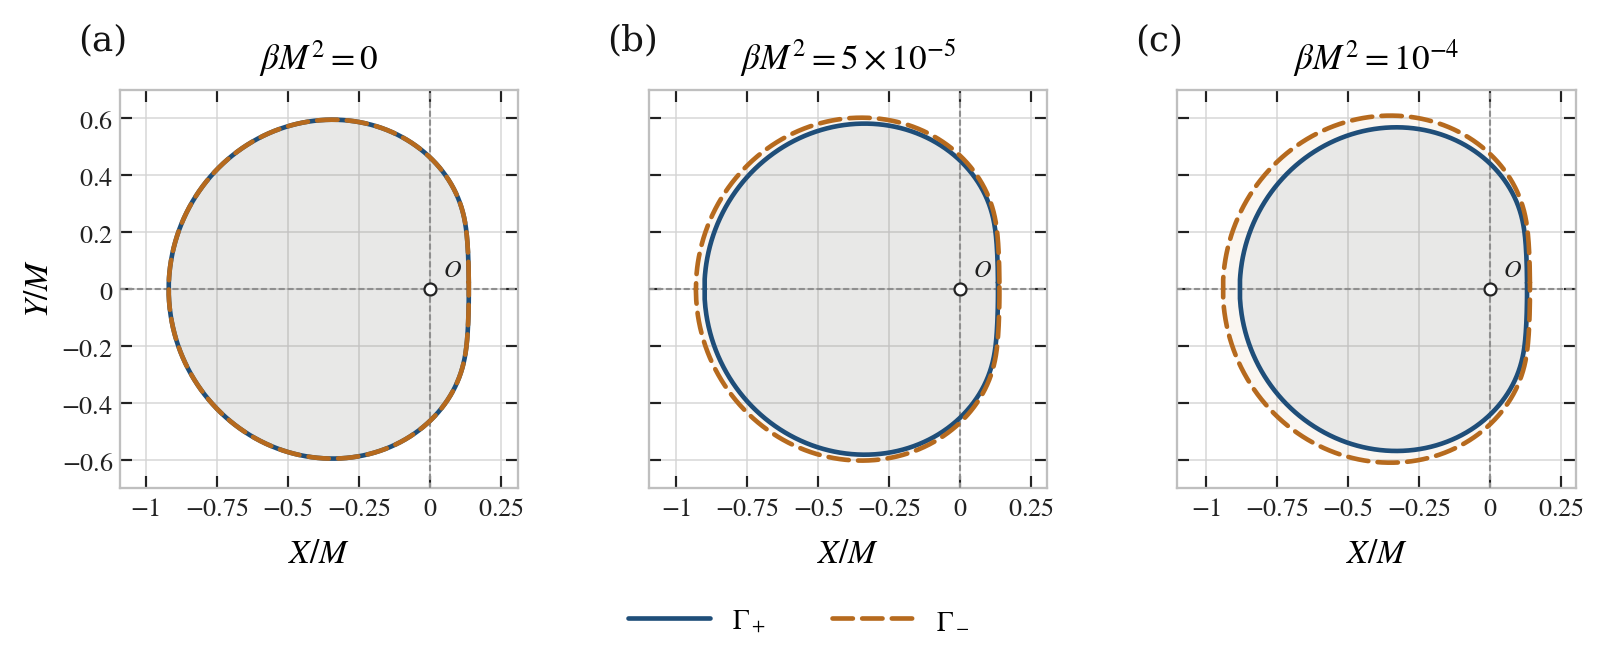

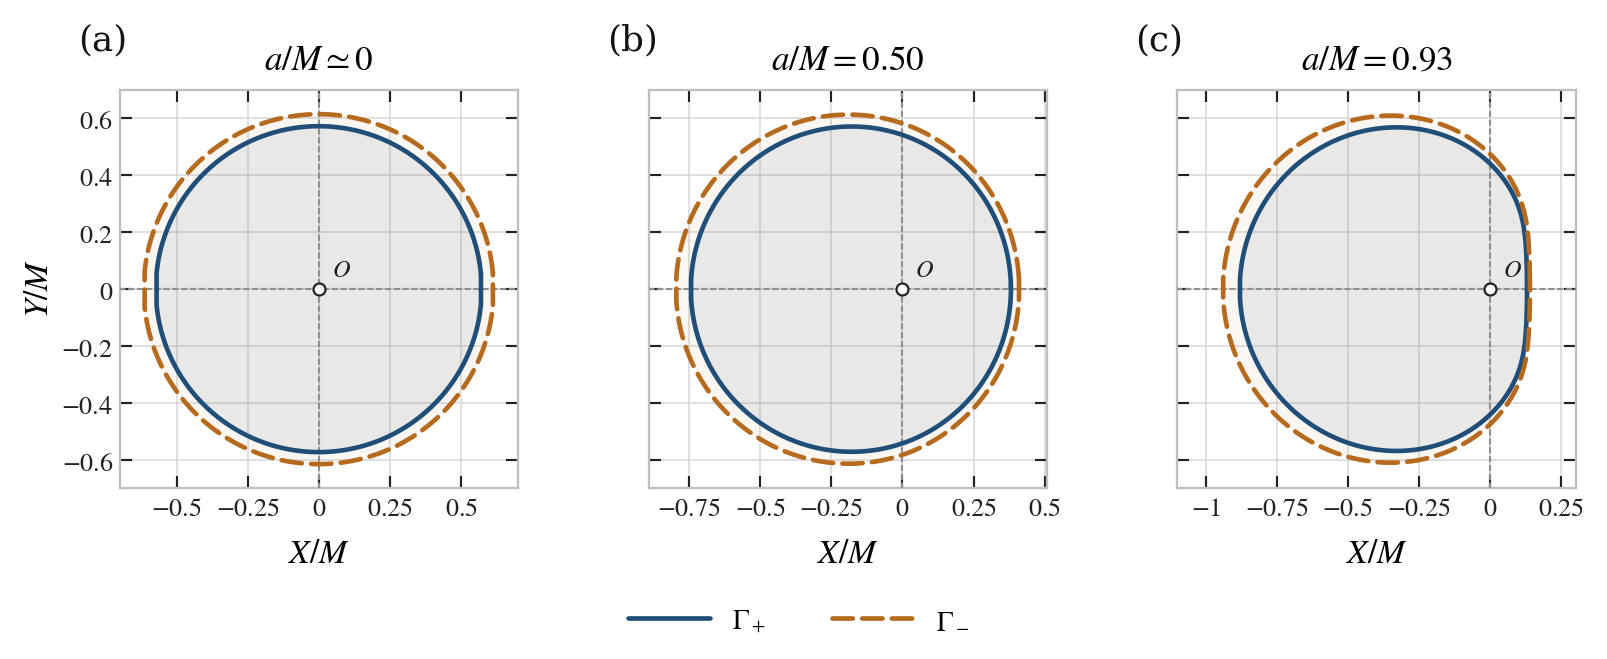

Figura beta guardada en:
  PDF: salidas_GD_birefringencia/figuras/figure_beta_contours_soft_filled.pdf
  PNG: salidas_GD_birefringencia/figuras/figure_beta_contours_soft_filled.png

Figura spin guardada en:
  PDF: salidas_GD_birefringencia/figuras/figure_spin_contours_soft_filled.pdf
  PNG: salidas_GD_birefringencia/figuras/figure_spin_contours_soft_filled.png


In [8]:
# ==============================================================================
#                         Ejecución de las figuras
# ==============================================================================

BASE_MODEL = GDModelParams(
    M=1.0,                                                                      # Escala de masa
    a=0.93,                                                                     # Rotación base
    p=0.20,                                                                     # Carga magnética
    q=0.30,                                                                     # Carga eléctrica
    beta=1.0e-4,                                                                # Acoplamiento no lineal base
    r_obs=8.0,                                                                  # Radio del observador
    theta_obs_deg=85.0,                                                         # Inclinación del observador
)

BASE_NUM = GDNumerics(
    Nrc=4500,                                                                   # Resolución del barrido radial crítico
    Nphi_static=1800,                                                           # Resolución angular del caso casi esférico
    r_crit_max=None,                                                            # Usa el corte radial automático
    horizon_root_tol=1.0e-9,                                                    # Tolerancia para raíces del horizonte
    eps_horizon=1.0e-5,                                                         # Margen mínimo fuera del horizonte
    eps_root=1.0e-12,                                                           # Umbral para evitar raíces degeneradas
    signature_tol=1.0e-11,                                                      # Margen para el dominio óptico regular
    static_spin_tol=1.0e-12,                                                    # Umbral para activar el caso esférico exacto
    small_a_threshold=5.0e-2,                                                   # Umbral para tratar giros pequeños con cuidado
    small_a_window_factor=20.0,                                                 # Amplía la ventana crítica cuando a es pequeño
    small_a_min_window=2.0e-3,                                                  # Ventana mínima cerca del límite esférico
)

BETA_VALUES = [0.0, 5.0e-5, 1.0e-4]                                             # Valores del barrido en βM²
SPIN_VALUES = [1.0e-3, 0.50, 0.93]                                              # Valores del barrido en a/M


BETA_MODEL = replace(
    BASE_MODEL,
    a=0.93,                                                                     # Mantiene alta rotación en el barrido de β
    p=0.20,
    q=0.30,
    r_obs=8.0,
    theta_obs_deg=85.0,
)                                                                               # Modelo base para variar sólo β

beta_results = compute_scan(
    param_name="beta",
    values=BETA_VALUES,
    base_model=BETA_MODEL,
    num=BASE_NUM,
)                                                                               # Calcula Γ+ y Γ− para cada β

fig_beta_pdf, fig_beta_png = plot_contour_triptych(
    results_list=beta_results,
    values=BETA_VALUES,
    title_function=beta_panel_title,
    filename="figure_beta_contours_soft_filled",
    padding=0.12,                                                               # Margen visual alrededor de los contornos
    min_half=0.70,                                                              # Semiancho mínimo de pantalla
    origin_margin=0.06,                                                         # Garantiza que el origen quede visible
    round_step=0.05,                                                            # Redondea límites a escalas limpias
    axis_label_x=r"$X/M$",
    global_axis_label_y=r"$Y/M$",
)                                                                               # Genera y guarda el tríptico en β


SPIN_MODEL = replace(
    BASE_MODEL,
    beta=1.0e-4,                                                                # Mantiene fija la no linealidad
    p=0.20,
    q=0.30,
    r_obs=8.0,
    theta_obs_deg=85.0,
)                                                                               # Modelo base para variar sólo a/M

spin_results = compute_scan(
    param_name="a",
    values=SPIN_VALUES,
    base_model=SPIN_MODEL,
    num=BASE_NUM,
)                                                                               # Calcula Γ+ y Γ− para cada rotación

fig_spin_pdf, fig_spin_png = plot_contour_triptych(
    results_list=spin_results,
    values=SPIN_VALUES,
    title_function=spin_panel_title,
    filename="figure_spin_contours_soft_filled",
    padding=0.12,                                                               # Mantiene el mismo margen visual
    min_half=0.70,                                                              # Mantiene la misma escala mínima
    origin_margin=0.06,                                                         # Conserva visible el origen local
    round_step=0.05,                                                            # Usa límites comparables y limpios
    axis_label_x=r"$X/M$",
    global_axis_label_y=r"$Y/M$",
)                                                                               # Genera y guarda el tríptico en a/M


print("Figura beta guardada en:")
print(f"  PDF: {fig_beta_pdf}")
print(f"  PNG: {fig_beta_png}")

print("\nFigura spin guardada en:")
print(f"  PDF: {fig_spin_pdf}")
print(f"  PNG: {fig_spin_png}")


## **(3) Tablas de observables geométricos**

Se construyen las tablas que resumen los observables geométricos asociados al desdoblamiento birefringente de los contornos críticos. Se consideran tres barridos independientes,

$10^4\beta M^2,\qquad a/M,\qquad \theta_o$ ,

manteniendo fija la configuración de referencia

$M=1,\qquad p=0.2,\qquad q=0.3,\qquad r_o=8.$

La salida numérica se conserva en dos niveles. Los archivos crudos mantienen los valores tal como salen del cálculo, incluyendo residuos de punto flotante. La versión destinada a publicación sólo limpia residuos compatibles con cero en el límite de Maxwell, evitando que errores numéricos del orden de la precisión de máquina aparezcan como una señal física espuria.

### **Control de residuos numéricos**

Antes de construir las tablas, definimos algunas rutinas de higiene numérica. En particular, la separación angular se evalúa mediante una forma estable basada en `atan2`, lo que evita falsos no-cero cuando las dos direcciones comparadas son prácticamente coincidentes.

In [9]:
# ==============================================================================
#                         Control de residuos numéricos
# ==============================================================================

RAW_ZERO_TOL = 1.0e-13                                                          # Umbral para diagnosticar residuos crudos
PUBLIC_ZERO_TOL = 5.0e-8                                                        # Umbral para limpiar ceros en tablas publicables


def angular_distance_unit(u, v):
    """
    Distancia angular estable entre dos vectores unitarios tridimensionales.

    La forma arccos(u·v) puede amplificar errores de redondeo cuando los
    vectores casi coinciden. En cambio, atan2(||u×v||, u·v) usa información
    del seno y del coseno del ángulo, por lo que es más estable cerca de cero.
    """

    u = np.asarray(u, dtype=float)                                              # Convierte la primera dirección a arreglo real
    v = np.asarray(v, dtype=float)                                              # Convierte la segunda dirección a arreglo real

    cross_norm = np.linalg.norm(
        np.cross(u, v)
    )                                                                           # Mide la parte transversal entre direcciones

    dot = float(
        np.clip(
            np.dot(u, v),
            -1.0,
            1.0,
        )
    )                                                                           # Mantiene el producto interno dentro del dominio angular

    return float(
        np.arctan2(cross_norm, dot)
    )                                                                           # Devuelve la separación angular en radianes


def angular_distance_2d(u, v):
    """
    Distancia angular estable entre dos direcciones normalizadas en el plano.

    Esta versión se usa cuando sólo interesa comparar orientaciones proyectadas
    sobre la pantalla. El determinante representa la parte transversal en 2D,
    mientras que el producto interno representa la parte longitudinal.
    """

    u = np.asarray(u, dtype=float)                                              # Convierte la primera dirección plana
    v = np.asarray(v, dtype=float)                                              # Convierte la segunda dirección plana

    det = float(
        u[0] * v[1] - u[1] * v[0]
    )                                                                           # Área orientada entre ambas direcciones

    dot = float(
        np.clip(
            np.dot(u, v),
            -1.0,
            1.0,
        )
    )                                                                           # Protege el dominio frente a redondeo

    return float(
        np.arctan2(abs(det), dot)
    )                                                                           # Devuelve el ángulo no orientado en radianes


def clean_public_zero(x, tol=PUBLIC_ZERO_TOL):
    """
    Limpia ceros numéricos sólo para la versión publicable de las tablas.

    Esta función no modifica los datos crudos. Su único objetivo es evitar que
    residuos de redondeo compatibles con cero aparezcan como una separación
    física en el límite de Maxwell.
    """

    if x is None or not np.isfinite(x):
        return x                                                                # Conserva entradas vacías o no finitas

    return 0.0 if abs(float(x)) < tol else float(x)                             # Limpia sólo residuos bajo tolerancia


### **Configuración global**

Agrupamos en una sola clase los parámetros físicos, geométricos y numéricos que se usarán para construir las tablas. Esta configuración fija el modelo base, define los tres barridos reportados en el manuscrito y establece los controles de resolución, tolerancia perturbativa y salida de archivos. La idea es que las tablas puedan regenerarse cambiando sólo esta celda, sin tocar las rutinas de cálculo.

In [10]:
# ==============================================================================
#                           Configuración global
# ==============================================================================

@dataclass
class Params:
    M: float = 1.0                                                              # Escala de masa
    p: float = 0.2                                                              # Carga magnética
    q: float = 0.3                                                              # Carga eléctrica
    r_obs: float = 8.0                                                          # Radio del observador
    theta_obs_deg: float = 85.0                                                 # Inclinación base del observador

    beta_scan_values: tuple = (0.0, 0.3, 0.5, 0.7, 1.0)                         # Barrido en acoplamiento no lineal
    a_scan_values: tuple = (0.0, 0.3, 0.6, 0.93)                                # Barrido en rotación
    theta_scan_values: tuple = (17.0, 45.0, 60.0, 85.0)                         # Barrido en inclinación

    A_STAR_OVER_M: float = 0.93                                                 # Rotación fija de referencia
    BETA_STAR_M2: float = 1.0e-4                                                # Acoplamiento fijo de referencia
    THETA_STAR_DEG: float = 85.0                                                # Inclinación fija de referencia

    EPS_MAX: float = 0.05                                                       # Cota máxima admitida para epsilon_pert

    # Si es True, las filas con epsilon_pert > EPS_MAX se eliminan
    # sólo de las tablas LaTeX. Los CSV conservan todos los datos.
    DROP_NONPERTURBATIVE_FROM_LATEX: bool = False                               # Conserva trazabilidad completa en archivos crudos

    alpha_plus: float = 8.0                                                     # Coeficiente de la rama Γ+
    alpha_minus: float = -4.0                                                   # Coeficiente de la rama Γ−

    # Controles numéricos.
    n_rc: int = 3000                                                            # Resolución del radio crítico
    n_theta_eps: int = 220                                                      # Resolución angular para epsilon_pert
    n_r_eps: int = 260                                                          # Resolución radial para epsilon_pert
    n_phi_spherical: int = 1500                                                 # Resolución angular del caso esférico

    sigma_r: int = +1                                                           # Orientación radial local del rayo

    outdir: str = os.path.join(
        "salidas_GD_birefringencia",
        "tablas",
    )                                                                           # Ruta donde se guardan CSV y LaTeX


P = Params()                                                                    # Instancia única de configuración
os.makedirs(P.outdir, exist_ok=True)                                            # Crea la carpeta de tablas si no existe


### **Funciones de fondo**

Definimos ahora las funciones geométricas básicas del espacio-tiempo de García--Díaz: la carga diónica cuadrática, el ángulo local del observador, los bloques $\Sigma$, $\Delta$, su derivada radial y el horizonte exterior. Estas funciones constituyen la base común para calcular las ramas ópticas, los contornos críticos y los observables geométricos de las tablas.

In [11]:
# ==============================================================================
#                           Funciones de fondo
# ==============================================================================

def Q2(P=P):
    """Carga diónica cuadrática Q_c^2 = p^2 + q^2."""
    return P.p**2 + P.q**2                                                      # Combinación de cargas del fondo


def theta_obs(P=P):
    """Ángulo polar del observador en radianes."""
    return np.deg2rad(P.theta_obs_deg)                                          # Convierte grados a radianes


def Sigma(r, theta, a):
    """Bloque geométrico Sigma = r^2 + a^2 cos^2(theta)."""
    return r**2 + a**2 * np.cos(theta)**2                                       # Factor común del fondo rotante


def Delta(r, a, beta, P=P):
    """
    Función radial de García--Díaz.

    Delta(r) =
    r^2 + a^2 - 2 M r
    + (p^2+q^2) [1 - beta (r^2+a^2)]^2.
    """

    return (
        r**2
        + a**2
        - 2.0 * P.M * r
        + Q2(P) * (1.0 - beta * (r**2 + a**2))**2
    )                                                                           # Función radial que fija horizonte y potenciales


def Delta_prime(r, a, beta, P=P):
    """
    Derivada radial de Delta.

    Si K = 1 - beta(r^2+a^2), entonces
    Delta' = 2r - 2M - 4 beta Q_c^2 r K.
    """

    K = 1.0 - beta * (r**2 + a**2)                                              # Factor no lineal radial
    return (
        2.0 * r
        - 2.0 * P.M
        - 4.0 * beta * Q2(P) * r * K
    )                                                                           # Derivada usada en condiciones críticas


def outer_horizon(a, beta, P=P):
    """
    Horizonte exterior del fondo.

    Se obtiene como la mayor raíz real positiva de Delta(r)=0.
    Para beta diferente de cero, Delta es cuártica; en el límite beta=0,
    la misma construcción se reduce al polinomio cuadrático de Kerr--Newman.
    """

    q2 = Q2(P)                                                                  # Carga diónica cuadrática
    M = P.M                                                                     # Masa del fondo

    c4 = q2 * beta**2                                                           # Coeficiente del término r^4
    c3 = 0.0                                                                    # No aparece término cúbico
    c2 = 1.0 - 2.0 * beta * q2 + 2.0 * beta**2 * a**2 * q2
    c1 = -2.0 * M                                                               # Término lineal gravitacional
    c0 = a**2 + q2 * (1.0 - 2.0 * beta * a**2 + beta**2 * a**4)

    coeffs = np.array(
        [c4, c3, c2, c1, c0],
        dtype=float,
    )                                                                           # Coeficientes de Delta(r)=0

    nz = np.flatnonzero(np.abs(coeffs) > 1.0e-15)                               # Localiza el primer coeficiente no nulo

    if len(nz) == 0:
        raise RuntimeError("Degenerate Delta polynomial.")

    coeffs = coeffs[nz[0]:]                                                     # Elimina ceros líderes en el límite beta=0
    roots = np.roots(coeffs)                                                    # Calcula raíces reales y complejas del polinomio

    real_pos = sorted(
        [
            z.real
            for z in roots
            if abs(z.imag) < 1.0e-9 and z.real > 0.0
        ]
    )                                                                           # Conserva sólo raíces reales positivas

    if not real_pos:
        raise RuntimeError(
            f"No positive horizon root found for a={a}, beta={beta}."
        )

    return max(real_pos)                                                        # Selecciona el horizonte exterior


### **Funciones de rama óptica**

Definimos los factores ópticos asociados a cada rama birefringente. Estas funciones codifican la separación entre $\Gamma_+$ y $\Gamma_-$ a través de los coeficientes $\alpha_s$, los bloques ópticos $A_s$ y $B_s$, y los factores locales $\Upsilon_s$ y $\Phi_s$ evaluados sobre los campos alineados en el límite de Maxwell.

In [12]:
# ==============================================================================
#                         Funciones de rama óptica
# ==============================================================================

def alpha_of(branch, P=P):
    """Devuelve el coeficiente óptico alpha_s de cada rama."""

    if branch == "+":
        return P.alpha_plus                                                     # Coeficiente de la rama Γ+

    if branch == "-":
        return P.alpha_minus                                                    # Coeficiente de la rama Γ−

    raise ValueError("branch must be '+' or '-'.")


def A_s(r, branch, beta, P=P):
    """Factor radial óptico A_s(r) = 1 + beta alpha_s r^2."""

    return (
        1.0
        + beta * alpha_of(branch, P) * r**2
    )                                                                           # Deforma el bloque radial de la rama


def A_s_prime(r, branch, beta, P=P):
    """Derivada radial de A_s."""

    return (
        2.0 * beta * alpha_of(branch, P) * r
    )                                                                           # Entra en la condición de raíz doble


def B_s(theta, branch, a, beta, P=P):
    """Factor angular óptico B_s(theta)."""

    return (
        1.0
        - beta * alpha_of(branch, P) * a**2 * np.cos(theta)**2
    )                                                                           # Deforma el bloque angular de la rama


def E0_B0(r, theta, a, P=P):
    """
    Campos alineados en el límite de Maxwell.

    Se evalúan en la tétrada principal usando
    x = a cos(theta), y = r y Sigma = x^2 + y^2.
    """

    x = a * np.cos(theta)                                                       # Coordenada auxiliar angular-rotante
    y = r                                                                       # Coordenada auxiliar radial
    Sig = x**2 + y**2                                                           # Sigma escrita como x^2+y^2

    Acal = (
        P.q * (x**2 - y**2)
        + 2.0 * P.p * x * y
    )                                                                           # Numerador del campo eléctrico alineado

    Ccal = (
        P.p * (y**2 - x**2)
        + 2.0 * P.q * x * y
    )                                                                           # Numerador del campo magnético alineado

    E0 = Acal / Sig**2                                                          # Campo eléctrico en el límite lineal
    B0 = Ccal / Sig**2                                                          # Campo magnético en el límite lineal

    return E0, B0


def nu_s(r, theta, a, beta, branch, P=P):
    """
    Coeficiente de Fresnel de primer orden.

    Controla la magnitud local de la corrección óptica de cada rama.
    """

    if beta == 0.0:
        return 0.0                                                              # En Maxwell no hay desdoblamiento óptico

    return (
        beta
        * alpha_of(branch, P)
        * Sigma(r, theta, a)**3
        / Q2(P)
    )                                                                           # Coeficiente local de la rama s


def optical_factors(r, theta, a, beta, branch, P=P):
    """
    Factores ópticos locales en la tétrada.

    Upsilon_s modifica la componente radial efectiva.
    Phi_s modifica las componentes angulares efectivas.
    """

    E0, B0 = E0_B0(r, theta, a, P)                                              # Campos de Maxwell evaluados localmente
    nu = nu_s(r, theta, a, beta, branch, P)                                     # Peso de Fresnel de la rama

    Upsilon = 1.0 + nu * E0**2                                                  # Factor asociado al sector eléctrico
    Phi = 1.0 - nu * B0**2                                                      # Factor asociado al sector magnético

    return Upsilon, Phi


def epsilon_pert(a, beta, P=P, r_L=None):
    """
    Parámetro de control perturbativo.

    Mide el máximo de |nu_s E0^2| y |nu_s B0^2| en el dominio exterior
    entre el horizonte y el radio de corte r_L. Si r_L no se especifica,
    se toma r_L = r_obs.
    """

    if beta == 0.0:
        return 0.0                                                              # El límite de Maxwell es exactamente perturbativo

    if r_L is None:
        r_L = P.r_obs                                                           # Usa el observador como corte radial natural

    try:
        r_plus = outer_horizon(a, beta, P)                                      # Horizonte exterior del fondo
    except Exception:
        r_plus = 0.0                                                            # Permite continuar si falla el diagnóstico de horizonte

    r_min = max(
        r_plus + 1.0e-5,
        1.0e-5,
    )                                                                           # Evita evaluar sobre el horizonte o en r=0

    r_max = max(
        r_L,
        r_min + 1.0e-3,
    )                                                                           # Garantiza un intervalo radial no degenerado

    rs = np.linspace(
        r_min,
        r_max,
        P.n_r_eps,
    )                                                                           # Malla radial para el diagnóstico perturbativo

    ths = np.linspace(
        1.0e-5,
        np.pi - 1.0e-5,
        P.n_theta_eps,
    )                                                                           # Malla angular sin tocar los polos

    maxval = 0.0                                                                # Acumula el máximo perturbativo

    for branch in ["+", "-"]:
        for r in rs:
            theta = ths                                                         # Evalúa todos los ángulos para este radio

            E0, B0 = E0_B0(r, theta, a, P)                                      # Campos sobre la malla angular
            nu = nu_s(r, theta, a, beta, branch, P)                             # Coeficiente local de la rama

            local = np.maximum(
                np.abs(nu * E0**2),
                np.abs(nu * B0**2),
            )                                                                   # Mayor corrección óptica local

            maxval = max(
                maxval,
                float(np.nanmax(local)),
            )                                                                   # Actualiza el supremo numérico

    return maxval


### **Constantes críticas**

A continuación se implementan las constantes críticas $\xi_s(r_c)$ y $k_s(r_c)$ para el caso rotante. Estas cantidades parametrizan la familia crítica de cada rama óptica y se obtienen imponiendo la condición de raíz doble del potencial radial efectivo.

In [13]:
# ==============================================================================
#                         Constantes críticas
# ==============================================================================

def Dfrak_s(r, a, beta, branch, P=P):
    """Combinación radial que aparece en la condición de raíz doble."""

    return (
        Delta_prime(r, a, beta, P) * A_s(r, branch, beta, P)
        - Delta(r, a, beta, P) * A_s_prime(r, branch, beta, P)
    )                                                                           # D_s = Delta' A_s - Delta A_s'


def xi_k_rotating(r_c, a, beta, branch, P=P):
    """
    Constantes críticas para el caso rotante.

    La parametrización es válida para a != 0. El límite esférico debe
    tratarse por separado porque las expresiones contienen divisiones por a.
    """

    if abs(a) < 1.0e-12:
        raise ValueError("xi_k_rotating is singular at a=0; use spherical limit.")

    Dc = Delta(r_c, a, beta, P)                                                 # Delta evaluada en el radio crítico
    As = A_s(r_c, branch, beta, P)                                              # Factor radial óptico en r_c
    Ds = Dfrak_s(r_c, a, beta, branch, P)                                       # Denominador efectivo de raíz doble

    if abs(Ds) < 1.0e-12 or Dc <= 0.0:
        return np.nan, np.nan                                                   # Descarta puntos degenerados o interiores

    xi = (
        ((r_c**2 + a**2) * Ds - 4.0 * r_c * Dc * As)
        / (a * Ds)
    )                                                                           # Parámetro crítico axial xi_s(r_c)

    k = (
        16.0 * r_c**2 * Dc * As**3 / Ds**2
    )                                                                           # Constante crítica tipo Carter k_s(r_c)

    return xi, k


### Proyección local

In [14]:
# ==============================================================================
#                Proyección en la esfera celeste local y pantalla
# ==============================================================================

def project_point_rotating(r_c, varsigma, a, beta, branch, P=P):
    """
    Proyecta un punto crítico rotante sobre la pantalla local.

    varsigma = +1 y varsigma = -1 seleccionan las mitades superior e
    inferior del contorno. La función devuelve None si el punto no es
    visible, no es real o cae fuera del dominio óptico admisible.
    """

    th_o = theta_obs(P)                                                         # Inclinación del observador
    r_o = P.r_obs                                                               # Radio del observador

    xi, k = xi_k_rotating(r_c, a, beta, branch, P)                              # Constantes críticas de la rama

    if not np.isfinite(xi) or not np.isfinite(k) or k <= 0.0:
        return None                                                             # Exige constantes críticas reales y admisibles

    Sig_o = Sigma(r_o, th_o, a)                                                 # Sigma en el observador
    Del_o = Delta(r_o, a, beta, P)                                              # Delta en el observador

    if Del_o <= 0.0 or Sig_o <= 0.0:
        return None                                                             # Exige observador en región exterior regular

    As_o = A_s(r_o, branch, beta, P)                                            # Factor radial óptico local
    Bs_o = B_s(th_o, branch, a, beta, P)                                        # Factor angular óptico local

    if As_o <= 0.0 or Bs_o <= 0.0:
        return None                                                             # Requiere firma óptica bien definida

    P_o = r_o**2 + a**2 - a * xi                                                # Bloque radial observado
    Q_o = xi - a * np.sin(th_o)**2                                              # Bloque angular observado

    Theta_o = k / Bs_o - Q_o**2 / np.sin(th_o)**2                               # Potencial angular en el observador
    R_o = P_o**2 - (Del_o / As_o) * k                                           # Potencial radial en el observador

    tol = 1.0e-12                                                               # Tolerancia para residuos negativos pequeños

    if Theta_o < -tol or R_o < -tol:
        return None                                                             # El punto crítico no llega al observador

    Theta_o = max(float(Theta_o), 0.0)                                          # Limpia residuos negativos de redondeo
    R_o = max(float(R_o), 0.0)                                                  # Limpia residuos negativos de redondeo

    p1 = (
        P.sigma_r * np.sqrt(R_o)
        / np.sqrt(Del_o * Sig_o)
    )                                                                           # Componente radial del covector local

    p2 = (
        varsigma * np.sqrt(Theta_o)
        / np.sqrt(Sig_o)
    )                                                                           # Componente polar del covector local

    p3 = (
        Q_o
        / (np.sqrt(Sig_o) * np.sin(th_o))
    )                                                                           # Componente azimutal del covector local

    U, Ph = optical_factors(r_o, th_o, a, beta, branch, P)                      # Factores ópticos locales

    if U <= 0.0 or Ph <= 0.0:
        return None                                                             # Descarta pérdida de dominio óptico

    # Dirección de transporte hamiltoniano:
    # K_s^{hat a} = g_eff^{hat a hat b} p_hat b.
    K1 = U * p1                                                                 # Componente radial transportada
    K2 = Ph * p2                                                                # Componente polar transportada
    K3 = Ph * p3                                                                # Componente azimutal transportada

    norm = np.sqrt(K1**2 + K2**2 + K3**2)                                       # Norma espacial de la dirección transportada

    if norm <= 0.0 or not np.isfinite(norm):
        return None                                                             # Evita direcciones degeneradas

    n1 = K1 / norm                                                              # Dirección unitaria radial
    n2 = K2 / norm                                                              # Dirección unitaria polar
    n3 = K3 / norm                                                              # Dirección unitaria azimutal

    # Proyección estereográfica sobre la pantalla local.
    denom = 1.0 + n1                                                            # Denominador de la estereografía

    if abs(denom) < 1.0e-12:
        return None                                                             # Evita la singularidad de proyección

    X = 2.0 * n3 / denom                                                        # Coordenada horizontal de pantalla
    Y = 2.0 * n2 / denom                                                        # Coordenada vertical de pantalla

    if not (np.isfinite(X) and np.isfinite(Y)):
        return None                                                             # Exige coordenadas proyectadas finitas

    return {
        "r_c": r_c,
        "varsigma": varsigma,
        "branch": branch,
        "xi": xi,
        "k": k,
        "n1": n1,
        "n2": n2,
        "n3": n3,
        "X": X,
        "Y": Y,
        "Theta_o": Theta_o,
        "R_o": R_o,
        "Upsilon_o": U,
        "Phi_o": Ph,
    }


def branch_curve_rotating(a, beta, branch, P=P):
    """
    Genera la curva proyectada Gamma_s de una rama óptica rotante.

    La mitad superior se recorre con varsigma=+1 y radio creciente.
    La mitad inferior se recorre con varsigma=-1 y radio decreciente.
    """

    r_plus = outer_horizon(a, beta, P)                                          # Horizonte exterior
    r_min = r_plus + 1.0e-5                                                     # Inicio del barrido fuera del horizonte
    r_max = P.r_obs * 0.999                                                     # Corte bajo el observador

    rows_plus = []                                                              # Mitad superior del contorno
    rows_minus = []                                                             # Mitad inferior del contorno

    for r_c in np.linspace(r_min, r_max, P.n_rc):
        for varsigma, bucket in [(+1, rows_plus), (-1, rows_minus)]:
            pt = project_point_rotating(
                r_c,
                varsigma,
                a,
                beta,
                branch,
                P,
            )                                                                   # Proyecta un punto crítico de la rama

            if pt is not None:
                bucket.append(pt)                                               # Conserva sólo puntos visibles

    rows_plus = sorted(
        rows_plus,
        key=lambda z: z["r_c"],
    )                                                                           # Orden radial de la mitad superior

    rows_minus = sorted(
        rows_minus,
        key=lambda z: z["r_c"],
        reverse=True,
    )                                                                           # Orden inverso para cerrar la curva

    return rows_plus + rows_minus


def paired_curve_rotating(a, beta, P=P):
    """
    Genera puntos emparejados donde ambas ramas son visibles.

    Esta lista se usa para calcular separaciones entre Γ+ y Γ−:
    Delta_cel, Delta_scr, w_br y f_br.
    """

    r_plus = outer_horizon(a, beta, P)                                          # Horizonte exterior
    r_min = r_plus + 1.0e-5                                                     # Inicio seguro del barrido radial
    r_max = P.r_obs * 0.999                                                     # Corte radial bajo el observador

    rows_top = []                                                               # Puntos emparejados de la mitad superior
    rows_bot = []                                                               # Puntos emparejados de la mitad inferior

    for r_c in np.linspace(r_min, r_max, P.n_rc):
        for varsigma, bucket in [(+1, rows_top), (-1, rows_bot)]:
            pp = project_point_rotating(
                r_c,
                varsigma,
                a,
                beta,
                "+",
                P,
            )                                                                   # Punto de Γ+ para el mismo r_c y varsigma

            pm = project_point_rotating(
                r_c,
                varsigma,
                a,
                beta,
                "-",
                P,
            )                                                                   # Punto de Γ− para el mismo r_c y varsigma

            if pp is None or pm is None:
                continue                                                        # Sólo compara puntos visibles en ambas ramas

            n_plus = np.array(
                [pp["n1"], pp["n2"], pp["n3"]],
                dtype=float,
            )                                                                   # Dirección celeste de Γ+

            n_minus = np.array(
                [pm["n1"], pm["n2"], pm["n3"]],
                dtype=float,
            )                                                                   # Dirección celeste de Γ−

            X_plus = np.array(
                [pp["X"], pp["Y"]],
                dtype=float,
            )                                                                   # Punto de pantalla de Γ+

            X_minus = np.array(
                [pm["X"], pm["Y"]],
                dtype=float,
            )                                                                   # Punto de pantalla de Γ−

            Delta_cel = angular_distance_unit(
                n_plus,
                n_minus,
            )                                                                   # Separación angular en la esfera celeste

            Delta_scr = float(
                np.linalg.norm(X_plus - X_minus)
            )                                                                   # Separación euclídea en la pantalla

            bucket.append({
                "r_c": r_c,
                "varsigma": varsigma,
                "n_plus": n_plus,
                "n_minus": n_minus,
                "X_plus": X_plus,
                "X_minus": X_minus,
                "Delta_cel": Delta_cel,
                "Delta_scr": Delta_scr,
            })                                                                  # Guarda el par geométrico comparable

    rows_top = sorted(
        rows_top,
        key=lambda z: z["r_c"],
    )                                                                           # Orden radial de la mitad superior

    rows_bot = sorted(
        rows_bot,
        key=lambda z: z["r_c"],
        reverse=True,
    )                                                                           # Orden inverso de la mitad inferior

    return rows_top + rows_bot


### **Límite esférico**

Tratamos por separado el caso $(a=0)$, porque las constantes críticas rotantes contienen divisiones por $(a)$ y no deben evaluarse directamente en el límite esférico. En este régimen, los contornos proyectados son circunferencias concéntricas y los observables pueden calcularse a partir del radio crítico, el parámetro de impacto efectivo y el radio de pantalla de cada rama óptica.

In [15]:
# ==============================================================================
#                          Límite esférico a = 0
# ==============================================================================

def b2_spherical(r, beta, branch, P=P):
    """
    Parámetro de impacto crítico al cuadrado en el límite esférico.
    """

    return (
        r**4
        * A_s(r, branch, beta, P)
        / Delta(r, 0.0, beta, P)
    )                                                                           # b_s^2 = r^4 A_s / Delta


def critical_radius_spherical(beta, branch, P=P):
    """
    Radio crítico esférico de una rama óptica.

    Se obtiene extremizando b_s^2(r), lo que equivale a resolver
    4/r + A_s'/A_s - Delta'/Delta = 0.
    """

    a = 0.0                                                                     # Límite no rotante
    r_plus = outer_horizon(a, beta, P)                                          # Horizonte exterior esférico
    r_min = r_plus + 1.0e-5                                                     # Inicio seguro fuera del horizonte
    r_max = P.r_obs * 0.999                                                     # Corte radial bajo el observador

    def F(r):
        return (
            4.0 / r
            + A_s_prime(r, branch, beta, P) / A_s(r, branch, beta, P)
            - Delta_prime(r, a, beta, P) / Delta(r, a, beta, P)
        )                                                                       # Ecuación crítica d(b_s^2)/dr = 0

    grid = np.linspace(r_min, r_max, 2500)                                      # Malla para detectar cambios de signo
    vals = np.array([F(x) for x in grid])                                       # Evalúa la condición crítica

    roots = []                                                                  # Guarda raíces refinadas

    for i in range(len(grid) - 1):
        if not np.isfinite(vals[i]) or not np.isfinite(vals[i + 1]):
            continue                                                            # Omite intervalos mal definidos

        if vals[i] == 0.0:
            roots.append(grid[i])                                               # Caso excepcional: raíz exacta en la malla

        elif vals[i] * vals[i + 1] < 0.0:
            try:
                roots.append(
                    brentq(F, grid[i], grid[i + 1], maxiter=200)
                )                                                               # Refina la raíz dentro del intervalo
            except ValueError:
                pass                                                            # Ignora intervalos numéricamente problemáticos

    if not roots:
        raise RuntimeError(
            f"No spherical critical radius found for beta={beta}, branch={branch}."
        )

    return max(roots)                                                           # Selecciona la raíz crítica exterior


def spherical_screen_radius(beta, branch, P=P):
    """
    Radio de pantalla de una rama óptica en el límite esférico.

    Devuelve:
        r_ph            radio crítico,
        b2              parámetro de impacto al cuadrado,
        screen_radius   radio estereográfico en pantalla,
        n1              componente radial local,
        n_perp          componente transversal local.
    """

    a = 0.0                                                                     # Límite esférico
    r_o = P.r_obs                                                               # Radio del observador
    th_o = theta_obs(P)                                                         # Inclinación del observador

    r_ph = critical_radius_spherical(beta, branch, P)                           # Radio crítico de la rama
    b2 = b2_spherical(r_ph, beta, branch, P)                                    # Impacto crítico al cuadrado

    Del_o = Delta(r_o, a, beta, P)                                              # Delta en el observador
    As_o = A_s(r_o, branch, beta, P)                                            # Factor radial óptico local

    R_o = r_o**4 - (Del_o / As_o) * b2                                          # Potencial radial observado

    if R_o < 0.0:
        raise RuntimeError("Spherical branch is not visible at observer.")

    p1 = (
        P.sigma_r
        * np.sqrt(max(R_o, 0.0))
        / (np.sqrt(Del_o) * r_o)
    )                                                                           # Componente radial local

    p_perp = np.sqrt(b2) / r_o                                                  # Componente transversal local

    U, Ph = optical_factors(r_o, th_o, a, beta, branch, P)                      # Factores ópticos locales

    K1 = U * p1                                                                 # Dirección radial transportada
    Kp = Ph * p_perp                                                            # Dirección transversal transportada

    norm = np.sqrt(K1**2 + Kp**2)                                               # Norma local bidimensional

    n1 = K1 / norm                                                              # Componente radial unitaria
    n_perp = Kp / norm                                                          # Componente transversal unitaria

    screen_radius = 2.0 * n_perp / (1.0 + n1)                                   # Radio estereográfico del círculo

    return r_ph, b2, screen_radius, n1, n_perp


def observables_spherical(beta, scan_label, scan_key, scan_value, P=P):
    """
    Observables geométricos en el límite esférico a = 0.
    """

    rph_p, b2p, Rp, n1p, nperpp = spherical_screen_radius(beta, "+", P)
    rph_m, b2m, Rm, n1m, nperpm = spherical_screen_radius(beta, "-", P)

    u_plus = np.array([n1p, nperpp], dtype=float)                               # Dirección local de Γ+
    u_minus = np.array([n1m, nperpm], dtype=float)                              # Dirección local de Γ−

    Delta_cel = angular_distance_2d(u_plus, u_minus)                            # Separación angular entre círculos
    Delta_scr = abs(Rp - Rm)                                                    # Separación radial en pantalla

    d_plus = 2.0 * Rp                                                           # Diámetro efectivo de Γ+
    d_minus = 2.0 * Rm                                                          # Diámetro efectivo de Γ−
    d0 = 0.5 * (d_plus + d_minus)                                               # Diámetro medio de referencia

    delta_d = (
        2.0 * abs(d_plus - d_minus) / (d_plus + d_minus)
    )                                                                           # Diferencia fraccional de diámetros

    # Para circunferencias concéntricas:
    # delta X_perp = Rp - Rm y w_br = |Rp - Rm|/2.
    w_br = 0.5 * abs(Rp - Rm)                                                   # Ancho birefringente efectivo
    f_br = w_br / d0 if d0 > 0.0 else np.nan                                    # Fracción relativa del ancho

    eps = epsilon_pert(0.0, beta, P, r_L=P.r_obs)                               # Control perturbativo del caso

    return {
        "scan": scan_label,
        "scan_key": scan_key,
        "scan_value": scan_value,
        "a": 0.0,
        "a_over_M": 0.0,
        "betaM2": beta * P.M**2,
        "beta_display_1e4": 1.0e4 * beta * P.M**2,
        "theta_obs_deg": P.theta_obs_deg,
        "epsilon_pert": eps,
        "epsilon_ok": eps <= P.EPS_MAX,
        "Delta_cel_max": Delta_cel,
        "Delta_cel_mean": Delta_cel,
        "Delta_scr_max": Delta_scr,
        "Delta_scr_mean": Delta_scr,
        "d_plus": d_plus,
        "d_minus": d_minus,
        "d0": d0,
        "delta_d_br": delta_d,
        "w_br": w_br,
        "f_br": f_br,
        "N_plus": P.n_phi_spherical,
        "N_minus": P.n_phi_spherical,
        "N_br": P.n_phi_spherical,
        "r_plus": outer_horizon(0.0, beta, P),
        "rcrit_min": min(rph_p, rph_m),
        "rcrit_max": max(rph_p, rph_m),
        "note": "OK" if eps <= P.EPS_MAX else "epsilon > cutoff",
    }


### **Geometría discreta de los contornos**

Para los casos rotantes, los contornos $\Gamma_+$ y $\Gamma_-$ se representan como curvas discretas sobre la pantalla local. A partir de estas curvas se calculan longitudes, centros geométricos, diámetros efectivos y el ancho birefringente asociado a la separación normal entre ambas ramas.

In [16]:
# ==============================================================================
#                     Geometría discreta de los contornos
# ==============================================================================

def points_from_curve(curve):
    """Extrae los puntos de pantalla como un arreglo Nx2."""

    if len(curve) == 0:
        return np.empty((0, 2))                                                 # Curva vacía

    return np.array(
        [[row["X"], row["Y"]] for row in curve],
        dtype=float,
    )                                                                           # Puntos proyectados en pantalla


def closed_segments(points):
    """
    Segmentos de una curva cerrada discreta.

    Devuelve vectores de segmento, longitudes y puntos medios.
    """

    if len(points) < 3:
        return None, None, None                                                 # No hay polígono cerrado útil

    nxt = np.roll(points, -1, axis=0)                                           # Siguiente punto, con cierre periódico
    seg = nxt - points                                                          # Vectores de cada segmento
    dl = np.linalg.norm(seg, axis=1)                                            # Longitudes de arco discretas
    mid = 0.5 * (points + nxt)                                                  # Puntos medios de los segmentos

    good = dl > 1.0e-14                                                         # Descarta segmentos degenerados

    return seg[good], dl[good], mid[good]


def effective_diameter(points):
    """
    Diámetro efectivo de un contorno cerrado.

    Se calcula a partir de la longitud total, el centro ponderado por
    longitud de arco y el radio medio respecto de ese centro.
    """

    seg, dl, mid = closed_segments(points)

    if seg is None or len(dl) == 0:
        return np.nan, np.nan, np.array([np.nan, np.nan])

    L = float(np.sum(dl))                                                       # Longitud total del contorno
    C = np.sum(mid * dl[:, None], axis=0) / L                                   # Centro ponderado por longitud

    Rbar = float(
        np.sum(np.linalg.norm(mid - C, axis=1) * dl) / L
    )                                                                           # Radio medio efectivo

    d = 2.0 * Rbar                                                              # Diámetro efectivo

    return d, L, C


def birefringent_width(paired_rows):
    """
    Ancho birefringente discreto.

    Se calcula proyectando la separación entre Γ+ y Γ− sobre la normal
    local del contorno medio.
    """

    if len(paired_rows) < 3:
        return np.nan, np.nan                                                   # No hay suficientes pares visibles

    Xp = np.array([row["X_plus"] for row in paired_rows], dtype=float)
    Xm = np.array([row["X_minus"] for row in paired_rows], dtype=float)

    Xbar = 0.5 * (Xp + Xm)                                                      # Contorno medio
    dX = Xp - Xm                                                                # Separación entre ramas

    Xbar_next = np.roll(Xbar, -1, axis=0)                                       # Siguiente punto del contorno medio
    dX_next = np.roll(dX, -1, axis=0)                                           # Siguiente separación entre ramas

    seg = Xbar_next - Xbar                                                      # Segmentos del contorno medio
    dl = np.linalg.norm(seg, axis=1)                                            # Longitudes discretas

    good = dl > 1.0e-14                                                         # Descarta segmentos degenerados

    if not np.any(good):
        return np.nan, np.nan

    seg = seg[good]
    dl = dl[good]

    dX_mid = 0.5 * (dX[good] + dX_next[good])                                   # Separación evaluada en puntos medios

    t_hat = seg / dl[:, None]                                                   # Tangente unitaria del contorno medio

    # Normal en el plano de pantalla: m_hat = (-t_y, t_x).
    m_hat = np.column_stack((-t_hat[:, 1], t_hat[:, 0]))

    delta_perp = np.sum(dX_mid * m_hat, axis=1)                                 # Separación normal entre ramas

    Lbar = float(np.sum(dl))                                                    # Longitud del contorno medio

    w2 = float(
        np.sum((delta_perp**2) * dl) / (4.0 * Lbar)
    )                                                                           # Promedio cuadrático normal

    return np.sqrt(max(w2, 0.0)), Lbar


### **Cálculo de observables**

Finalmente se ensamblan los observables geométricos usados en las tablas: separación angular máxima y media, separación en pantalla, diámetros efectivos, diferencia fraccional de diámetro, ancho birefringente y fracción relativa $f_{\rm br}$. Esta celda también organiza los tres barridos reportados en el manuscrito y separa la salida cruda de la versión limpia destinada a publicación.

In [17]:
# ==============================================================================
#                         Cálculo de observables
# ==============================================================================

def observables_rotating(a, beta, scan_label, scan_key, scan_value, P=P):
    """
    Calcula todos los observables geométricos para un caso rotante.
    """

    curve_p = branch_curve_rotating(a, beta, "+", P)                            # Contorno Γ+
    curve_m = branch_curve_rotating(a, beta, "-", P)                            # Contorno Γ−
    paired = paired_curve_rotating(a, beta, P)                                  # Puntos visibles en ambas ramas

    pts_p = points_from_curve(curve_p)                                          # Puntos de pantalla de Γ+
    pts_m = points_from_curve(curve_m)                                          # Puntos de pantalla de Γ−

    d_plus, L_plus, C_plus = effective_diameter(pts_p)
    d_minus, L_minus, C_minus = effective_diameter(pts_m)

    d0 = 0.5 * (d_plus + d_minus)                                               # Diámetro medio de referencia

    if d_plus + d_minus > 0.0:
        delta_d = (
            2.0 * abs(d_plus - d_minus) / (d_plus + d_minus)
        )                                                                       # Diferencia fraccional de diámetros
    else:
        delta_d = np.nan

    if paired:
        Delta_cel_vals = np.array([row["Delta_cel"] for row in paired])
        Delta_scr_vals = np.array([row["Delta_scr"] for row in paired])

        Delta_cel_max = float(np.nanmax(Delta_cel_vals))
        Delta_cel_mean = float(np.nanmean(Delta_cel_vals))

        Delta_scr_max = float(np.nanmax(Delta_scr_vals))
        Delta_scr_mean = float(np.nanmean(Delta_scr_vals))

    else:
        Delta_cel_max = np.nan
        Delta_cel_mean = np.nan
        Delta_scr_max = np.nan
        Delta_scr_mean = np.nan

    w_br, Lbar = birefringent_width(paired)                                     # Ancho birefringente global

    f_br = (
        w_br / d0
        if d0 and np.isfinite(d0) and d0 > 0.0
        else np.nan
    )                                                                           # Ancho relativo al diámetro medio

    eps = epsilon_pert(a, beta, P, r_L=P.r_obs)                                 # Diagnóstico de validez perturbativa

    rcs = [row["r_c"] for row in paired]                                        # Radios críticos emparejados visibles

    return {
        "scan": scan_label,
        "scan_key": scan_key,
        "scan_value": scan_value,
        "a": a,
        "a_over_M": a / P.M,
        "betaM2": beta * P.M**2,
        "beta_display_1e4": 1.0e4 * beta * P.M**2,
        "theta_obs_deg": P.theta_obs_deg,
        "epsilon_pert": eps,
        "epsilon_ok": eps <= P.EPS_MAX,
        "Delta_cel_max": Delta_cel_max,
        "Delta_cel_mean": Delta_cel_mean,
        "Delta_scr_max": Delta_scr_max,
        "Delta_scr_mean": Delta_scr_mean,
        "d_plus": d_plus,
        "d_minus": d_minus,
        "d0": d0,
        "delta_d_br": delta_d,
        "w_br": w_br,
        "f_br": f_br,
        "N_plus": len(curve_p),
        "N_minus": len(curve_m),
        "N_br": len(paired),
        "r_plus": outer_horizon(a, beta, P),
        "rcrit_min": float(np.nanmin(rcs)) if rcs else np.nan,
        "rcrit_max": float(np.nanmax(rcs)) if rcs else np.nan,
        "note": "OK" if eps <= P.EPS_MAX else "epsilon > cutoff",
    }


def compute_one_case(a, beta, scan_label, scan_key, scan_value, P=P):
    """
    Selecciona automáticamente entre el caso esférico y el rotante.
    """

    if abs(a) < 1.0e-12:
        return observables_spherical(
            beta,
            scan_label,
            scan_key,
            scan_value,
            P,
        )                                                                       # Usa la reducción esférica exacta

    return observables_rotating(
        a,
        beta,
        scan_label,
        scan_key,
        scan_value,
        P,
    )                                                                           # Usa la construcción rotante


def prepare_table_dataframe(df, clean_for_publication=True):
    """
    Prepara columnas compactas para las tablas.

    Si clean_for_publication=True, se limpian sólo residuos compatibles
    con cero en límites exactos. Los datos crudos deben guardarse con
    clean_for_publication=False.
    """

    df = df.copy()                                                              # Evita modificar la tabla de entrada

    biref_cols = [
        "Delta_cel_max",
        "Delta_cel_mean",
        "Delta_scr_max",
        "Delta_scr_mean",
        "delta_d_br",
        "w_br",
        "f_br",
    ]                                                                           # Columnas que deben anularse en Maxwell

    if clean_for_publication:
        for col in biref_cols:
            if col in df.columns:
                df[col] = df[col].map(clean_public_zero)                        # Limpieza de residuos de presentación

        # Chequeo exacto del límite de Maxwell en la capa publicable.
        if "betaM2" in df.columns:
            maxwell_mask = np.isclose(
                df["betaM2"],
                0.0,
                atol=1.0e-16,
            )                                                                   # Filas del límite lineal exacto

            for col in biref_cols:
                if col in df.columns:
                    df.loc[maxwell_mask, col] = 0.0                             # Fuerza splitting nulo en Maxwell

            # En Maxwell las dos ramas ópticas coinciden.
            if {"d_plus", "d_minus", "d0"}.issubset(df.columns):
                dbar = 0.5 * (
                    df.loc[maxwell_mask, "d_plus"]
                    + df.loc[maxwell_mask, "d_minus"]
                )

                df.loc[maxwell_mask, "d_plus"] = dbar
                df.loc[maxwell_mask, "d_minus"] = dbar
                df.loc[maxwell_mask, "d0"] = dbar

    df["1e4_Delta_cel_max"] = 1.0e4 * df["Delta_cel_max"]
    df["1e4_Delta_cel_mean"] = 1.0e4 * df["Delta_cel_mean"]
    df["100_delta_d_br"] = 100.0 * df["delta_d_br"]
    df["100_f_br"] = 100.0 * df["f_br"]

    return df


def build_all_tables(P=P):
    """
    Construye los tres barridos de las tablas:

      1) barrido en beta con a y theta_o fijos,
      2) barrido en a/M con beta y theta_o fijos,
      3) barrido en theta_o con a y beta fijos.
    """

    rows = []                                                                   # Acumula todas las filas crudas

    # --------------------------------------------------------------------------
    # Barrido 1: variaciòn de beta.
    # La variable mostrada es 10^4 beta M^2.
    # --------------------------------------------------------------------------
    for beta_display in P.beta_scan_values:
        beta = beta_display * 1.0e-4 / P.M**2                                   # Convierte la escala mostrada a beta
        a = P.A_STAR_OVER_M * P.M                                               # Mantiene fija la rotación
        P_case = replace(P, theta_obs_deg=P.THETA_STAR_DEG)

        rows.append(
            compute_one_case(
                a=a,
                beta=beta,
                scan_label=r"$10^4\beta M^2$-scan",
                scan_key="beta",
                scan_value=beta_display,
                P=P_case,
            )
        )

    # --------------------------------------------------------------------------
    # Barrido 2: variaciòn de spin.
    # La variable mostrada es a/M.
    # --------------------------------------------------------------------------
    for a_over_M in P.a_scan_values:
        beta = P.BETA_STAR_M2 / P.M**2                                          # Mantiene fijo beta M^2
        a = a_over_M * P.M                                                      # Convierte a/M en a
        P_case = replace(P, theta_obs_deg=P.THETA_STAR_DEG)

        rows.append(
            compute_one_case(
                a=a,
                beta=beta,
                scan_label=r"$a/M$-scan",
                scan_key="spin",
                scan_value=a_over_M,
                P=P_case,
            )
        )

    # --------------------------------------------------------------------------
    # Barrido 3: variaciòn de inclinación del observador.
    # La variable mostrada es theta_o en grados.
    # --------------------------------------------------------------------------
    for theta_deg in P.theta_scan_values:
        beta = P.BETA_STAR_M2 / P.M**2                                          # Mantiene fijo beta M^2
        a = P.A_STAR_OVER_M * P.M                                               # Mantiene fija la rotación
        P_case = replace(P, theta_obs_deg=theta_deg)

        rows.append(
            compute_one_case(
                a=a,
                beta=beta,
                scan_label=r"$\theta_o$-scan",
                scan_key="inclination",
                scan_value=theta_deg,
                P=P_case,
            )
        )

    raw_full = pd.DataFrame(rows)                                               # Tabla cruda de todos los barridos
    raw_full = prepare_table_dataframe(
        raw_full,
        clean_for_publication=False,
    )                                                                           # Conserva residuos numéricos crudos

    public_full = prepare_table_dataframe(
        raw_full,
        clean_for_publication=True,
    )                                                                           # Limpia sólo la capa de publicación

    latex_full = public_full.copy()                                             # Base para tablas LaTeX

    if P.DROP_NONPERTURBATIVE_FROM_LATEX:
        latex_full = latex_full[latex_full["epsilon_ok"]].copy()                # Filtro opcional por validez

    beta_df = latex_full[latex_full["scan_key"] == "beta"].copy()
    spin_df = latex_full[latex_full["scan_key"] == "spin"].copy()
    theta_df = latex_full[latex_full["scan_key"] == "inclination"].copy()

    return raw_full, public_full, beta_df, spin_df, theta_df


### **Exportación LaTeX**

En esta etapa se preparan las salidas finales de las tablas. Primero se definen funciones de formateo para escribir números compatibles con columnas S de `siunitx`; luego se construyen los encabezados, títulos, leyendas y etiquetas de cada barrido. Finalmente, se exportan los archivos CSV completos y las tablas LaTeX en formato compatible con `REVTeX`, usando ruledtabular para mantener una presentación compacta y consistente con el manuscrito.

In [18]:
# ==============================================================================
#                             Exportación LaTeX
# ==============================================================================

def tex_plain(x, digits=4):
    """
    Convierte un número a cadena decimal para columnas S de siunitx.

    Los valores ausentes o no finitos se protegen como texto LaTeX.
    """

    if x is None or not np.isfinite(x):
        return r"{\cdots}"                                                      # Entrada protegida para columnas numéricas

    return f"{float(x):.{digits}f}"                                             # Decimal con precisión fija


def tex_int(x):
    """
    Convierte un valor numérico a entero para columnas S de siunitx.
    """

    if x is None or not np.isfinite(x):
        return r"{\cdots}"                                                      # Entrada protegida para valores faltantes

    return str(int(round(float(x))))                                            # Entero redondeado para conteos


def table_preamble():
    """
    Fragmento de preámbulo LaTeX para las tablas.

    Debe incluirse una vez si el manuscrito todavía no configura siunitx.
    REVTeX proporciona el entorno ruledtabular.
    """

    return r"""
% Required in the preamble:
% \usepackage{siunitx}
% REVTeX supplies ruledtabular.
\sisetup{
  detect-all,
  table-number-alignment = center,
  round-mode = places,
  round-pad = true,
  output-decimal-marker = {.}
}
\newcommand{\tabhead}[1]{\multicolumn{1}{c}{\(#1\)}}
""".strip()


def caption_for_scan(scan_key, P=P):
    """
    Construye la leyenda de cada tabla.

    La leyenda concentra las condiciones comunes y evita repetir
    epsilon_pert fila por fila.
    """

    common = (
        r"Se fija \(M=" + f"{P.M:g}" + r"\), "
        r"\(p=" + f"{P.p:g}" + r"\), "
        r"\(q=" + f"{P.q:g}" + r"\) y "
        r"\(r_o=" + f"{P.r_obs:g}" + r"\). "
        r"No se muestra \(\epsilon_{\rm pert}\) fila por fila para evitar "
        r"redundancia; el criterio usado para aceptar el régimen óptico es "
        r"\(\epsilon_{\rm pert}\le " + f"{P.EPS_MAX:.2f}" + r"\), "
        r"y sus valores completos quedan en el archivo CSV. "
        r"Las columnas \(\Delta_{\max}\), "
        r"\(\langle\Delta_{\rm cel}\rangle\), "
        r"\(\delta d_{\rm br}\) y \(f_{\rm br}\) se reportan como "
        r"\(10^4\Delta_{\max}\), "
        r"\(10^4\langle\Delta_{\rm cel}\rangle\), "
        r"\(10^2\delta d_{\rm br}\) y "
        r"\(10^2 f_{\rm br}\), respectivamente."
    )                                                                           # Condiciones comunes a las tres tablas

    if scan_key == "beta":
        lead = (
            r"Barrido en el acoplamiento no lineal \(\beta\) para los "
            r"contornos críticos \(\Gamma_+\) y \(\Gamma_-\). "
            r"Se fija \(a/M=" + f"{P.A_STAR_OVER_M:g}" + r"\) y "
            r"\(\theta_o=" + f"{P.THETA_STAR_DEG:g}" + r"^\circ\). "
        )                                                                       # Descripción del barrido en beta

    elif scan_key == "spin":
        lead = (
            r"Barrido en rotación para los contornos críticos "
            r"\(\Gamma_+\) y \(\Gamma_-\). "
            r"Se fija \(\beta M^2=10^{-4}\) y "
            r"\(\theta_o=" + f"{P.THETA_STAR_DEG:g}" + r"^\circ\). "
        )                                                                       # Descripción del barrido en a/M

    elif scan_key == "inclination":
        lead = (
            r"Barrido en inclinación del observador para los contornos críticos "
            r"\(\Gamma_+\) y \(\Gamma_-\). "
            r"Se fija \(a/M=" + f"{P.A_STAR_OVER_M:g}" + r"\) y "
            r"\(\beta M^2=10^{-4}\). "
        )                                                                       # Descripción del barrido en theta_o

    else:
        lead = r"Observables geométricos birrefringentes. "

    return lead + common


def scan_table_label(scan_key):
    """
    Etiqueta LaTeX de cada tabla.
    """

    return {
        "beta": "tab:prd_beta_scan_observables",
        "spin": "tab:prd_spin_scan_observables",
        "inclination": "tab:prd_inclination_scan_observables",
    }[scan_key]


def scan_table_title(scan_key):
    """
    Título de la primera columna según el parámetro barrido.
    """

    return {
        "beta": r"10^4\beta M^2",
        "spin": r"a/M",
        "inclination": r"\theta_o({}^{\circ})",
    }[scan_key]


def write_scan_latex(df, path, scan_key, P=P):
    """
    Escribe una tabla REVTeX/PRD compacta.

    La tabla incluye los observables geométricos principales y algunos
    diagnósticos auxiliares. epsilon_pert no aparece fila por fila porque
    se documenta en la leyenda y se conserva completo en los CSV.
    """

    lines = []                                                                  # Acumula líneas del archivo .tex

    lines.append(r"\begin{table*}[t]")                                          # Tabla ancha de dos columnas
    lines.append(r"\centering")
    lines.append(r"\caption{")
    lines.append(caption_for_scan(scan_key, P))                                 # Leyenda específica del barrido
    lines.append(r"}")
    lines.append(r"\label{" + scan_table_label(scan_key) + r"}")
    lines.append(r"\begingroup")
    lines.append(r"\scriptsize")                                                # Tamaño compacto para muchas columnas
    lines.append(r"\setlength{\tabcolsep}{2.0pt}")                              # Reduce separación horizontal
    lines.append(r"\renewcommand{\arraystretch}{1.08}")                         # Ajuste vertical moderado
    lines.append(r"\begin{ruledtabular}")                                       # Estilo REVTeX con reglas
    lines.append(r"\begin{tabular}{")
    lines.append(r"S[table-format=3.2]")                                        # Variable del barrido
    lines.append(r"S[table-format=1.5]")                                        # r_+
    lines.append(r"S[table-format=1.5]")                                        # r_c min
    lines.append(r"S[table-format=1.5]")                                        # r_c max
    lines.append(r"S[table-format=4.3]")                                        # 10^4 Delta max
    lines.append(r"S[table-format=4.3]")                                        # 10^4 Delta mean
    lines.append(r"S[table-format=1.5]")                                        # Delta_scr max
    lines.append(r"S[table-format=1.5]")                                        # Delta_scr mean
    lines.append(r"S[table-format=1.5]")                                        # d_+
    lines.append(r"S[table-format=1.5]")                                        # d_-
    lines.append(r"S[table-format=1.5]")                                        # d_0
    lines.append(r"S[table-format=2.4]")                                        # 10^2 delta d_br
    lines.append(r"S[table-format=1.5]")                                        # w_br
    lines.append(r"S[table-format=2.4]")                                        # 10^2 f_br
    lines.append(r"S[table-format=4.0]")                                        # N_br
    lines.append(r"}")
    lines.append(r"\tabhead{" + scan_table_title(scan_key) + r"} &")
    lines.append(r"\tabhead{r_+} &")
    lines.append(r"\tabhead{r_c^{\rm min}} &")
    lines.append(r"\tabhead{r_c^{\rm max}} &")
    lines.append(r"\tabhead{10^4\Delta_{\max}} &")
    lines.append(r"\tabhead{10^4\langle\Delta_{\rm cel}\rangle} &")
    lines.append(r"\tabhead{\Delta_{\rm scr}^{\max}} &")
    lines.append(r"\tabhead{\langle\Delta_{\rm scr}\rangle} &")
    lines.append(r"\tabhead{d_+} &")
    lines.append(r"\tabhead{d_-} &")
    lines.append(r"\tabhead{d_0} &")
    lines.append(r"\tabhead{10^2\delta d_{\rm br}} &")
    lines.append(r"\tabhead{w_{\rm br}} &")
    lines.append(r"\tabhead{10^2 f_{\rm br}} &")
    lines.append(r"\tabhead{N_{\rm br}} \\")
    lines.append(r"\hline")

    for _, row in df.iterrows():
        if scan_key == "inclination":
            scan_digits = 0                                                     # theta_o se muestra como entero
        else:
            scan_digits = 2                                                     # beta-display y a/M usan dos decimales

        vals = [
            tex_plain(row["scan_value"], scan_digits),
            tex_plain(row["r_plus"], 5),
            tex_plain(row["rcrit_min"], 5),
            tex_plain(row["rcrit_max"], 5),
            tex_plain(row["1e4_Delta_cel_max"], 3),
            tex_plain(row["1e4_Delta_cel_mean"], 3),
            tex_plain(row["Delta_scr_max"], 5),
            tex_plain(row["Delta_scr_mean"], 5),
            tex_plain(row["d_plus"], 5),
            tex_plain(row["d_minus"], 5),
            tex_plain(row["d0"], 5),
            tex_plain(row["100_delta_d_br"], 4),
            tex_plain(row["w_br"], 5),
            tex_plain(row["100_f_br"], 4),
            tex_int(row["N_br"]),
        ]                                                                       # Valores de una fila en orden de columnas

        lines.append(" & ".join(vals) + r" \\")                                 # Fila LaTeX completa

    lines.append(r"\end{tabular}")
    lines.append(r"\end{ruledtabular}")
    lines.append(r"\endgroup")
    lines.append(r"\end{table*}")

    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))                                               # Escribe la tabla individual


def write_all_tables_file(paths, outpath):
    """
    Concatena la configuración siunitx y las tres tablas LaTeX.
    """

    chunks = [table_preamble(), ""]                                             # Incluye preámbulo común

    for p in paths:
        with open(p, "r", encoding="utf-8") as f:
            chunks.append(f.read())                                             # Agrega cada tabla
        chunks.append("\n")

    with open(outpath, "w", encoding="utf-8") as f:
        f.write("\n".join(chunks))                                              # Escribe el archivo combinado


def save_outputs(raw_full_df, public_full_df, beta_df, spin_df, theta_df, P=P):
    """
    Guarda salidas CSV y LaTeX.

    Se generan dos CSV globales:
      - full_observables_all_scans_raw.csv conserva los valores crudos.
      - full_observables_all_scans_public.csv aplica limpieza de presentación.

    Además, se escriben CSV y tablas LaTeX para cada barrido.
    """

    os.makedirs(P.outdir, exist_ok=True)                                        # Asegura la carpeta de salida

    # Salidas legibles por máquina.
    raw_full_path = os.path.join(P.outdir, "full_observables_all_scans_raw.csv")
    public_full_path = os.path.join(P.outdir, "full_observables_all_scans_public.csv")
    beta_csv = os.path.join(P.outdir, "beta_scan_observables.csv")
    spin_csv = os.path.join(P.outdir, "spin_scan_observables.csv")
    theta_csv = os.path.join(P.outdir, "inclination_scan_observables.csv")

    raw_full_df.to_csv(raw_full_path, index=False)                              # Tabla completa sin limpieza visual
    public_full_df.to_csv(public_full_path, index=False)                        # Tabla completa lista para lectura
    beta_df.to_csv(beta_csv, index=False)                                       # Barrido en beta
    spin_df.to_csv(spin_csv, index=False)                                       # Barrido en a/M
    theta_df.to_csv(theta_csv, index=False)                                     # Barrido en theta_o

    # Tablas LaTeX listas para el manuscrito.
    beta_tex = os.path.join(P.outdir, "table_beta_scan.tex")
    spin_tex = os.path.join(P.outdir, "table_spin_scan.tex")
    theta_tex = os.path.join(P.outdir, "table_inclination_scan.tex")

    write_scan_latex(beta_df, beta_tex, "beta", P)                              # Tabla LaTeX del barrido en beta
    write_scan_latex(spin_df, spin_tex, "spin", P)                              # Tabla LaTeX del barrido en a/M
    write_scan_latex(theta_df, theta_tex, "inclination", P)                     # Tabla LaTeX del barrido angular

    all_tex = os.path.join(P.outdir, "tables_all.tex")
    write_all_tables_file(
        [beta_tex, spin_tex, theta_tex],
        all_tex,
    )                                                                           # Archivo único con las tres tablas

    return {
        "raw_full_csv": raw_full_path,
        "public_full_csv": public_full_path,
        "beta_csv": beta_csv,
        "spin_csv": spin_csv,
        "theta_csv": theta_csv,
        "beta_tex": beta_tex,
        "spin_tex": spin_tex,
        "theta_tex": theta_tex,
        "all_tex": all_tex,
    }                                                                           # Registro de todas las salidas


### **Ejecución de las tablas**

En esta celda se construyen las tres tablas de observables geométricos y se escriben las salidas en disco. La tabla mostrada corresponde a la versión publicable, donde sólo se limpian residuos compatibles con cero en límites exactos. Los CSV crudos se conservan junto con los archivos LaTeX para mantener trazabilidad completa del cálculo.

In [19]:
# ==============================================================================
#                          Ejecución de las tablas
# ==============================================================================

raw_full_df, public_full_df, beta_df, spin_df, theta_df = build_all_tables(P)
outputs = save_outputs(
    raw_full_df,
    public_full_df,
    beta_df,
    spin_df,
    theta_df,
    P,
)                                                                               # Construye y guarda CSV + LaTeX

pd.set_option("display.max_columns", None)                                      # Muestra todas las columnas seleccionadas
pd.set_option("display.width", 220)                                             # Evita cortes incómodos en pantalla

display_columns = [
    "scan_key",
    "scan_value",
    "a_over_M",
    "beta_display_1e4",
    "theta_obs_deg",
    "epsilon_pert",
    "epsilon_ok",
    "1e4_Delta_cel_max",
    "1e4_Delta_cel_mean",
    "Delta_scr_max",
    "Delta_scr_mean",
    "d_plus",
    "d_minus",
    "d0",
    "100_delta_d_br",
    "w_br",
    "100_f_br",
    "r_plus",
    "rcrit_min",
    "rcrit_max",
    "N_br",
    "note",
]                                                                               # Columnas relevantes para inspección rápida

display(
    public_full_df[display_columns]
)                                                                               # Muestra la versión usada en las tablas del paper

print("\nArchivos escritos:")

for key, val in outputs.items():
    print(
        f"{key:>15s}: {os.path.abspath(val)}"
    )                                                                           # Reporta rutas absolutas de salida


,scan_key,scan_value,a_over_M,beta_display_1e4,theta_obs_deg,epsilon_pert,epsilon_ok,1e4_Delta_cel_max,1e4_Delta_cel_mean,Delta_scr_max,Delta_scr_mean,d_plus,d_minus,d0,100_delta_d_br,w_br,100_f_br,r_plus,rcrit_min,rcrit_max,N_br,note
0,beta,0.00,0.93,0.0,85.0,0.000000,True,0.000000,0.000000,0.000000,0.000000,1.138227,1.138227,1.138227,0.000000,0.000000,0.000000,1.071414,1.087578,3.856731,2402,OK
1,beta,0.30,0.93,0.3,85.0,0.013671,True,601.122807,109.375130,0.072669,0.012129,1.122680,1.146093,1.134387,2.063928,0.006224,0.548641,1.071524,1.087687,3.849874,2396,OK
2,beta,0.50,0.93,0.5,85.0,0.022785,True,820.870309,180.935533,0.099119,0.020045,1.112485,1.151415,1.131950,3.439270,0.010263,0.906657,1.071597,1.087760,3.845303,2392,OK
3,beta,0.70,0.93,0.7,85.0,0.031899,True,996.340564,251.676423,0.120170,0.027858,1.102420,1.156774,1.129597,4.811812,0.014233,1.260035,1.071670,1.087833,3.840731,2388,OK
4,beta,1.00,0.93,1.0,85.0,0.045570,True,1212.097126,356.444809,0.145952,0.039410,1.087559,1.164932,1.126245,6.870051,0.020075,1.782503,1.071780,1.087942,3.833874,2382,OK
5,spin,0.00,0.00,1.0,85.0,0.035446,True,390.695916,390.695916,0.042514,0.042514,1.145018,1.230047,1.187533,7.160084,0.021257,1.790021,1.932790,2.904190,2.914123,1500,OK
6,spin,0.30,0.30,1.0,85.0,0.038920,True,1469.277097,435.671035,0.164731,0.047584,1.140993,1.225487,1.183240,7.140944,0.020436,1.727114,1.883230,2.533021,3.233726,690,OK
7,spin,0.60,0.60,1.0,85.0,0.042215,True,1183.030351,385.202166,0.137141,0.042359,1.128283,1.210790,1.169536,7.054670,0.020306,1.736276,1.714203,2.070073,3.531192,1398,OK
8,spin,0.93,0.93,1.0,85.0,0.045570,True,1212.097126,356.444809,0.145952,0.039410,1.087559,1.164932,1.126245,6.870051,0.020075,1.782503,1.071780,1.087942,3.833874,2382,OK
9,inclination,17.00,0.93,1.0,17.0,0.045570,True,1281.167602,390.542010,0.141668,0.042057,1.049561,1.129806,1.089684,7.364028,0.019593,1.798070,1.071780,1.890954,2.818572,806,OK



Archivos escritos:
   raw_full_csv: /content/salidas_GD_birefringencia/tablas/full_observables_all_scans_raw.csv
public_full_csv: /content/salidas_GD_birefringencia/tablas/full_observables_all_scans_public.csv
       beta_csv: /content/salidas_GD_birefringencia/tablas/beta_scan_observables.csv
       spin_csv: /content/salidas_GD_birefringencia/tablas/spin_scan_observables.csv
      theta_csv: /content/salidas_GD_birefringencia/tablas/inclination_scan_observables.csv
       beta_tex: /content/salidas_GD_birefringencia/tablas/table_beta_scan.tex
       spin_tex: /content/salidas_GD_birefringencia/tablas/table_spin_scan.tex
      theta_tex: /content/salidas_GD_birefringencia/tablas/table_inclination_scan.tex
        all_tex: /content/salidas_GD_birefringencia/tablas/tables_all.tex


## **(4) Validaciones**

El límite de Maxwell exige

$$
\Gamma_+=\Gamma_-,
\qquad
\Delta_{\rm cel}^{\rm max}
=
\langle\Delta_{\rm cel}\rangle
=
\Delta_{\rm scr}^{\rm max}
=
\delta d_{\rm br}
=
w_{\rm br}
=
f_{\rm br}
=
0 .
$$

En cambio, la fila $(a/M=0)$ con $(\beta\neq0)$ no tiene por qué anularse: corresponde al límite esférico con respuesta constitutiva activa, donde las ramas ópticas siguen siendo físicamente distintas.

In [20]:
# ==============================================================================
#                               Validaciones
# ==============================================================================

biref_cols = [
    "Delta_cel_max",
    "Delta_cel_mean",
    "Delta_scr_max",
    "Delta_scr_mean",
    "delta_d_br",
    "w_br",
    "f_br",
]                                                                               # Observables que deben anularse en Maxwell

maxwell = public_full_df[
    np.isclose(
        public_full_df["betaM2"],
        0.0,
        atol=1.0e-16,
    )
]                                                                               # Filas del límite lineal exacto

assert np.all(
    maxwell[biref_cols].abs().to_numpy() < 1.0e-14
)                                                                               # beta=0: las ramas Γ+ y Γ− colapsan

assert public_full_df["epsilon_ok"].all()                                       # Todas las filas respetan el corte perturbativo

display(
    public_full_df[
        [
            "scan_key",
            "scan_value",
            "epsilon_pert",
            "epsilon_ok",
        ]
    ]
)                                                                               # Revisión compacta del dominio perturbativo

print("Validaciones superadas.")


,scan_key,scan_value,epsilon_pert,epsilon_ok
0,beta,0.00,0.000000,True
1,beta,0.30,0.013671,True
2,beta,0.50,0.022785,True
3,beta,0.70,0.031899,True
4,beta,1.00,0.045570,True
5,spin,0.00,0.035446,True
6,spin,0.30,0.038920,True
7,spin,0.60,0.042215,True
8,spin,0.93,0.045570,True
9,inclination,17.00,0.045570,True


Validaciones superadas.


## **(5) Archivos generados**

Las figuras se guardan en

```text
salidas_GD_birefringencia/figuras/
```

y las tablas en

```text
salidas_GD_birefringencia/tablas/
```

Los archivos PDF se usan directamente en el manuscrito. Los PNG permiten inspección rápida, mientras que los CSV conservan las salidas numéricas completas para revisión y reproducibilidad.


In [21]:
for subdir in ["figuras", "tablas"]:
    folder = os.path.join(
        "salidas_GD_birefringencia",
        subdir,
    )                                                                           # Carpeta de salida a inspeccionar

    print(f"\n{subdir}/")

    for name in sorted(os.listdir(folder)):
        print(
            "  ",
            os.path.join(folder, name),
        )                                                                       # Lista archivos generados en orden alfabético



figuras/
   salidas_GD_birefringencia/figuras/figure_beta_contours_soft_filled.pdf
   salidas_GD_birefringencia/figuras/figure_beta_contours_soft_filled.png
   salidas_GD_birefringencia/figuras/figure_spin_contours_soft_filled.pdf
   salidas_GD_birefringencia/figuras/figure_spin_contours_soft_filled.png

tablas/
   salidas_GD_birefringencia/tablas/beta_scan_observables.csv
   salidas_GD_birefringencia/tablas/full_observables_all_scans_public.csv
   salidas_GD_birefringencia/tablas/full_observables_all_scans_raw.csv
   salidas_GD_birefringencia/tablas/inclination_scan_observables.csv
   salidas_GD_birefringencia/tablas/spin_scan_observables.csv
   salidas_GD_birefringencia/tablas/table_beta_scan.tex
   salidas_GD_birefringencia/tablas/table_inclination_scan.tex
   salidas_GD_birefringencia/tablas/table_spin_scan.tex
   salidas_GD_birefringencia/tablas/tables_all.tex
